In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/student-lifestyle-dataset/student_lifestyle_dataset.csv


### Dataset Overview: Student Lifestyle and Stress Analysis 📊

#### **🎯 Objective**:
The dataset provides insights into student lifestyle patterns and their relationship with stress levels and academic performance. It includes various lifestyle attributes such as study hours, sleep duration, physical activity, social hours, extracurricular activities, and GPA, which collectively influence students' stress levels.

#### **🔑 Key Characteristics**:
1. **📏 Size and Structure**:
   - **Number of Records**: 2,000
   - **Number of Columns**: 8
   - Features include both numerical and categorical variables.

2. **📋 Features**:
   - **Lifestyle Attributes**:
     - 🕒 `Study_Hours_Per_Day`: Daily time spent studying.
     - 😴 `Sleep_Hours_Per_Day`: Sleep duration per day.
     - 🏃‍♂️ `Physical_Activity_Hours_Per_Day`: Time dedicated to physical activities.
     - 🗣️ `Social_Hours_Per_Day`: Time spent socializing.
     - 🎭 `Extracurricular_Hours_Per_Day`: Time devoted to extracurricular activities.
   - **📈 Academic Performance**:
     - 🎓 `GPA`: Grade Point Average representing academic outcomes.
   - **⚡ Stress Level**:
     - Categorized into `Low`, `Moderate`, and `High` to indicate the intensity of stress experienced by students.

3. **🏷️ Categorical Features**:
   - ⚡ `Stress_Level`: Encoded into `Stress_Level_Encoded` for modeling purposes.
   - 🎓 `Academic_Performance`: Categorized into `Excellent`, `Good`, `Fair`, and `Poor` based on GPA and further encoded.

4. **🎯 Target Variable**:
   - The dataset focuses on **Stress_Level** as the target variable for predictive modeling.

#### **📊 Data Insights**:
- **🧠 Stress and Lifestyle Correlation**:
  - ⚡ High stress is associated with longer study hours and less sleep.
  - ⚖️ Moderate stress reflects a balance between academic and lifestyle activities.
  - 😊 Low stress is correlated with adequate physical activity and social interaction.
- **🔍 Feature Importance**:
  - 🕒 `Study_Hours_Per_Day` and 😴 `Sleep_Hours_Per_Day` are the most significant predictors of stress levels.
- **📊 Class Distribution**:
  - A significant proportion of students experience moderate to high stress, with relatively few maintaining low stress levels.


<div style="border-radius: 15px 0 15px 0px; border: 2px solid #f1c40f; padding: 10px; background-color: #191970; text-align: center; box-shadow: 0px 2px 4px rgba(0, 0, 0, 0.2);">
    <h1 style="color: #f1c40f; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px; font-size: 24px;">Imports and Setup</h1>
</div>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, accuracy_score, classification_report

import warnings
warnings.filterwarnings("ignore")

# <span style="color:transparent;">Load and Explore Dataset</span>

<div style="border-radius: 15px 0 15px 0px; border: 2px solid #f1c40f; padding: 10px; background-color: #191970; text-align: center; box-shadow: 0px 2px 4px rgba(0, 0, 0, 0.2);">
    <h1 style="color: #f1c40f; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px; font-size: 24px;">Load and Explore Dataset</h1>
</div>

In [3]:
# Load the dataset
df = pd.read_csv('/kaggle/input/student-lifestyle-dataset/student_lifestyle_dataset.csv')

In [4]:
# Display basic information about the dataset
print("Shape of the dataset:", df.shape)
display(df.head())
print("\nDataset Information:")
print(df.info())
print("\nStatistical Summary:")
display(df.describe().T)

Shape of the dataset: (2000, 8)


,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level
0,1,6.9,3.8,8.7,2.8,1.8,2.99,Moderate
1,2,5.3,3.5,8.0,4.2,3.0,2.75,Low
2,3,5.1,3.9,9.2,1.2,4.6,2.67,Low
3,4,6.5,2.1,7.2,1.7,6.5,2.88,Moderate
4,5,8.1,0.6,6.5,2.2,6.6,3.51,High



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Student_ID                       2000 non-null   int64  
 1   Study_Hours_Per_Day              2000 non-null   float64
 2   Extracurricular_Hours_Per_Day    2000 non-null   float64
 3   Sleep_Hours_Per_Day              2000 non-null   float64
 4   Social_Hours_Per_Day             2000 non-null   float64
 5   Physical_Activity_Hours_Per_Day  2000 non-null   float64
 6   GPA                              2000 non-null   float64
 7   Stress_Level                     2000 non-null   object 
dtypes: float64(6), int64(1), object(1)
memory usage: 125.1+ KB
None

Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
Student_ID,2000.0,1000.50000,577.494589,1.00,500.75,1000.50,1500.25,2000.0
Study_Hours_Per_Day,2000.0,7.47580,1.423888,5.00,6.30,7.40,8.70,10.0
Extracurricular_Hours_Per_Day,2000.0,1.99010,1.155855,0.00,1.00,2.00,3.00,4.0
Sleep_Hours_Per_Day,2000.0,7.50125,1.460949,5.00,6.20,7.50,8.80,10.0
Social_Hours_Per_Day,2000.0,2.70455,1.688514,0.00,1.20,2.60,4.10,6.0
Physical_Activity_Hours_Per_Day,2000.0,4.32830,2.514110,0.00,2.40,4.10,6.10,13.0
GPA,2000.0,3.11596,0.298674,2.24,2.90,3.11,3.33,4.0


#### **General Information**
1. **Dataset Dimensions**:
   - Rows: 2,000
   - Columns: 8
   - No missing values were found in any of the columns.

2. **Data Types**:
   - The dataset includes:
     - Numeric columns: 6 (e.g., hours spent on activities and GPA).
     - Categorical column: 1 (Stress Level).
     - ID column: 1 (Student_ID).

#### **Initial Observations**
1. **Balanced Lifestyle**:
   - Average hours spent on study, sleep, and physical activity are comparable, suggesting a relatively balanced lifestyle among students.

2. **GPA and Lifestyle Correlation**:
   - The relatively high mean GPA suggests a possible positive relationship between balanced lifestyle habits (e.g., sufficient sleep and study) and academic performance.

3. **Stress Levels**:
   - As a categorical feature, this can be further analyzed for correlations with GPA and other variables.

4. **Outliers**:
   - Physical activity hours (max: 13 hours) suggest some students are exceptionally active.
   - Social hours are also variable, ranging up to 6 hours daily, indicating diverse social habits.
udent_ID).

In [5]:
# Check for missing and duplicated values
print(f'\nMissing values: {df.isna().sum().sum()}')
print(f'Duplicated values: {df.duplicated().sum()}')


Missing values: 0
Duplicated values: 0


#### Missing and Duplicated Values

- **Missing Values**: 0  
  - The dataset is complete, with no missing entries in any column.
  
- **Duplicated Values**: 0  
  - There are no duplicate rows in the dataset.

# <span style="color:transparent;">Unique Value Exploration</span>

<div style="border-radius: 15px 0 15px 0px; border: 2px solid #f1c40f; padding: 10px; background-color: #191970; text-align: center; box-shadow: 0px 2px 4px rgba(0, 0, 0, 0.2);">
    <h1 style="color: #f1c40f; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px; font-size: 24px;">Unique Value Exploration</h1>
</div>

In [6]:
# Display the number of unique values in each column
print("\nUnique Values in Each Column:")
print(df.nunique())


Unique Values in Each Column:
Student_ID                         2000
Study_Hours_Per_Day                  51
Extracurricular_Hours_Per_Day        41
Sleep_Hours_Per_Day                  51
Social_Hours_Per_Day                 61
Physical_Activity_Hours_Per_Day     118
GPA                                 158
Stress_Level                          3
dtype: int64


In [7]:
# Separate numerical and categorical columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
non_numerical_columns = df.select_dtypes(include=['object']).columns.tolist()

# Display the lists of numerical and categorical columns
print("\nNumerical Columns:", numerical_columns)
print("Categorical Columns:", non_numerical_columns)


Numerical Columns: ['Student_ID', 'Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day', 'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day', 'Physical_Activity_Hours_Per_Day', 'GPA']
Categorical Columns: ['Stress_Level']


In [8]:
# Display unique values for each categorical column
for col in non_numerical_columns:
    print(f"\nColumn: {col}")
    print(f"Unique Values: {df[col].unique()}")


Column: Stress_Level
Unique Values: ['Moderate' 'Low' 'High']


#### Insights from Unique Value Exploration

1. **Rich Data Variety**:
   - **Numerical Columns**: Most columns, such as `Study_Hours_Per_Day`, `Sleep_Hours_Per_Day`, and `Physical_Activity_Hours_Per_Day`, exhibit a wide range of unique values (51–118). This indicates the data captures diverse lifestyle patterns among students.
   - **GPA**: With 158 unique values, it demonstrates that the academic performance metric is detailed and granular.

2. **Categorical Column**:
   - **Stress_Level**: Limited to 3 categories (`Moderate`, `Low`, `High`), making it ideal for categorical analysis and classification tasks.

3. **Unique Student Records**:
   - Each student has a distinct identifier (`Student_ID`), ensuring no duplicate entries and providing a clear mapping for individual analyses.

4. **Lifestyle Activities**:
   - **Physical Activity**: The highest number of unique values (118) among lifestyle-related features suggests significant variability in student engagement with physical activities.
   - **Social Hours**: Displays notable variability (61 unique values), which may highlight diverse social habits among students.

5. **Potential for Clustering**:
   - The broad ranges in numerical features like `Study_Hours_Per_Day`, `Extracurricular_Hours_Per_Day`, and `Sleep_Hours_Per_Day` indicate the potential for clustering students into lifestyle-based groups.

6. **Granularity in Academic Data**:
   - **GPA**: The high granularity of 158 unique values allows for precise academic performance analysis and modeling.

7. **Balanced Categorical Data**:
   - The three stress levels (`Moderate`, `Low`, `High`) make it easy to explore their relationship with numerical features like GPA and lifestyle habits.

# <span style="color:transparent;">Exploratory Data Analysis (EDA)</span>

<div style="border-radius: 15px 0 15px 0px; border: 2px solid #f1c40f; padding: 10px; background-color: #191970; text-align: center; box-shadow: 0px 2px 4px rgba(0, 0, 0, 0.2);">
    <h1 style="color: #f1c40f; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px; font-size: 24px;">Exploratory Data Analysis (EDA)</h1>
</div>

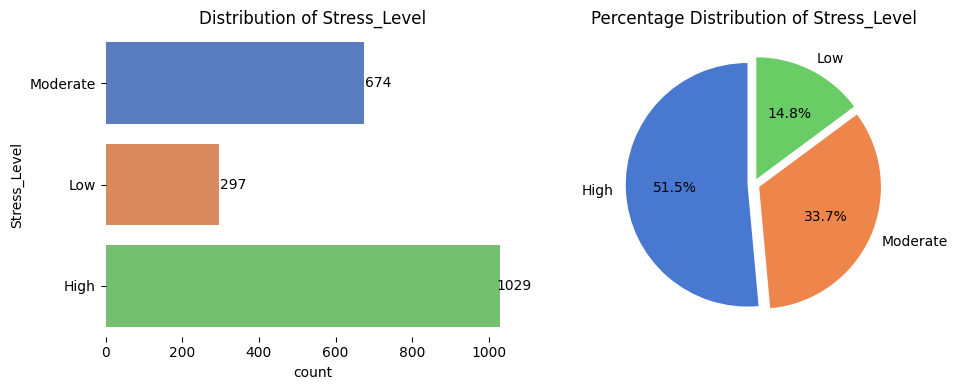

In [9]:
column_name = 'Stress_Level'
plt.figure(figsize=(10, 4))

# First subplot: Count plot
plt.subplot(1, 2, 1)
sns.countplot(y=column_name, data=df, palette='muted')  
plt.title(f'Distribution of {column_name}')

ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}', (p.get_width(), p.get_y() + p.get_height() / 2), 
                ha='center', va='center', xytext=(10, 0), textcoords='offset points')

sns.despine(left=True, bottom=True)

# Second subplot: Pie chart
plt.subplot(1, 2, 2)
df[column_name].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('muted'), startangle=90, explode=[0.05]*df[column_name].nunique())
plt.title(f'Percentage Distribution of {column_name}')
plt.ylabel('')  

plt.tight_layout()
plt.show()

#### Insights
1. **Distribution of Stress Levels**:
   - The most frequent stress level is **High**, comprising **51.5%** of the students (1,029 students). This indicates that over half of the students experience high stress levels, which could be due to academic, social, or lifestyle factors.
   - **Moderate stress** is the second most common category, making up **33.7%** of the students (674 students). This reflects a significant portion of students who manage their stress reasonably well.
   - A smaller proportion, **14.8%** (297 students), experiences **Low stress**. This indicates that only a minority of students have a well-balanced and stress-free lifestyle.

2. **Key Observations**:
   - **High Stress Dominance**:
     - The prevalence of high stress among students suggests a need to examine underlying causes, such as workload, lack of physical activity, or insufficient sleep.
   - **Moderate Stress**:
     - A third of the students are in this category, which could indicate a manageable but not ideal balance in their daily routines.
   - **Low Stress as a Minority**:
     - Less than 15% of students fall into the low-stress category, signaling that only a small fraction has an optimal balance between academic, social, and personal commitments.

3. **Implications**:
   - The majority of students (85.2%) face moderate to high stress levels. This could potentially impact academic performance and overall well-being.
   - Institutions or researchers could focus on interventions or strategies to help students reduce stress, such as promoting healthier habits (e.g., sufficient sleep, balanced socializing, and regular physical activity).

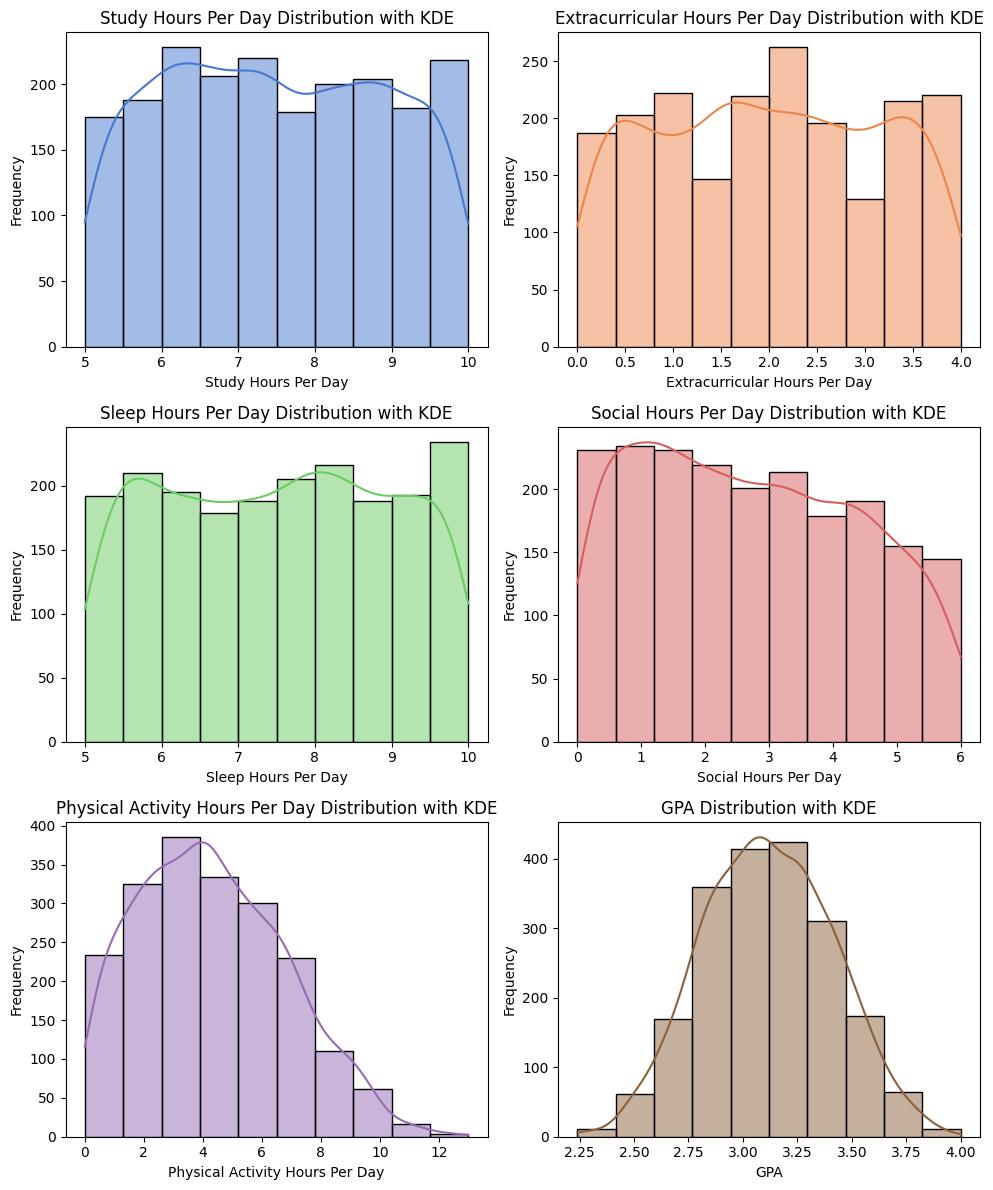

In [10]:
# Function to perform univariate analysis for numeric columns
def univariate_analysis(data, columns):
    plt.figure(figsize=(10, 12))  
    
    muted_colors = sns.color_palette("muted", len(columns))
    
    for i, column in enumerate(columns):
        plt.subplot(3, 2, i + 1)  
        sns.histplot(data[column], kde=True, bins=10, color=muted_colors[i])
        plt.title(f'{column.replace("_", " ")} Distribution with KDE')
        plt.xlabel(column.replace('_', ' '))
        plt.ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()

columns_to_analyze = ['Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day', 
                       'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day', 
                       'Physical_Activity_Hours_Per_Day', 'GPA']

univariate_analysis(df, columns_to_analyze)

#### Insights

1. **Study Hours Per Day**:
   - The distribution is slightly skewed to the right, with most students studying between **6 and 8 hours per day**.
   - Few students dedicate more than 9 hours daily to studying.

2. **Extracurricular Hours Per Day**:
   - A left-skewed distribution shows that **most students spend 0–2 hours daily** on extracurricular activities.
   - A smaller proportion engages in 3–4 hours of extracurriculars.

3. **Sleep Hours Per Day**:
   - The distribution is near normal, centered around **7–8 hours per day**.
   - Very few students sleep less than 6 hours or more than 9 hours.

4. **Social Hours Per Day**:
   - The distribution is right-skewed, with the majority spending **1–3 hours per day** socializing.
   - A smaller group spends significantly more time (4+ hours).

5. **Physical Activity Hours Per Day**:
   - A right-skewed distribution shows that most students engage in **2–5 hours of physical activity daily**.
   - A small proportion exceeds 8 hours, with outliers going beyond 10 hours.

6. **GPA**:
   - GPA follows a fairly normal distribution, peaking around **3.0–3.2**.
   - A few students achieve GPAs close to the maximum (4.0), while very few fall below 2.5.

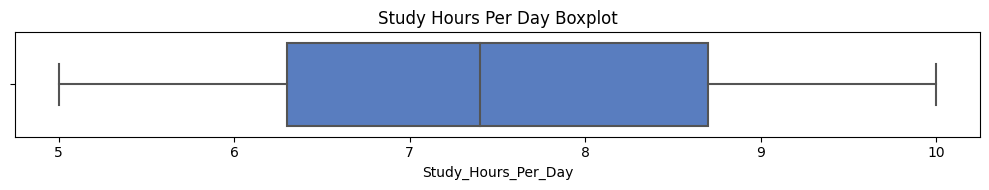


Summary Statistics for Study Hours Per Day:
 count    2000.000000
mean        7.475800
std         1.423888
min         5.000000
25%         6.300000
50%         7.400000
75%         8.700000
max        10.000000
Name: Study_Hours_Per_Day, dtype: float64


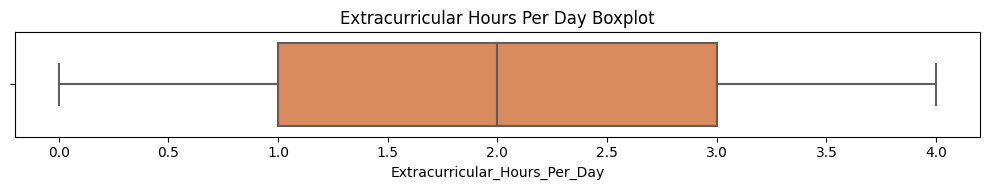


Summary Statistics for Extracurricular Hours Per Day:
 count    2000.000000
mean        1.990100
std         1.155855
min         0.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         4.000000
Name: Extracurricular_Hours_Per_Day, dtype: float64


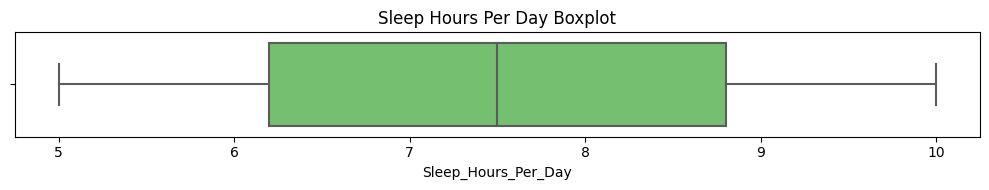


Summary Statistics for Sleep Hours Per Day:
 count    2000.000000
mean        7.501250
std         1.460949
min         5.000000
25%         6.200000
50%         7.500000
75%         8.800000
max        10.000000
Name: Sleep_Hours_Per_Day, dtype: float64


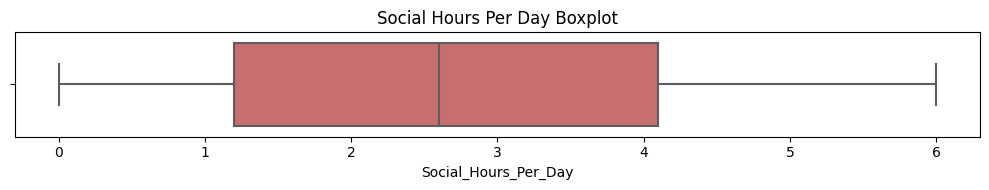


Summary Statistics for Social Hours Per Day:
 count    2000.000000
mean        2.704550
std         1.688514
min         0.000000
25%         1.200000
50%         2.600000
75%         4.100000
max         6.000000
Name: Social_Hours_Per_Day, dtype: float64


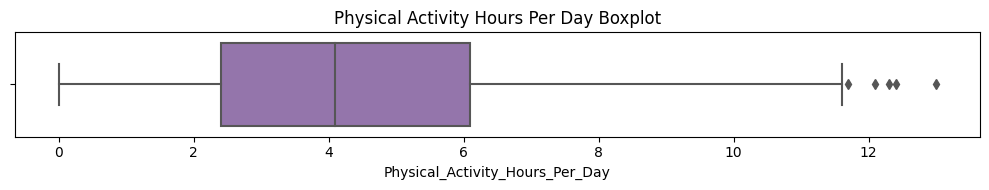


Summary Statistics for Physical Activity Hours Per Day:
 count    2000.00000
mean        4.32830
std         2.51411
min         0.00000
25%         2.40000
50%         4.10000
75%         6.10000
max        13.00000
Name: Physical_Activity_Hours_Per_Day, dtype: float64


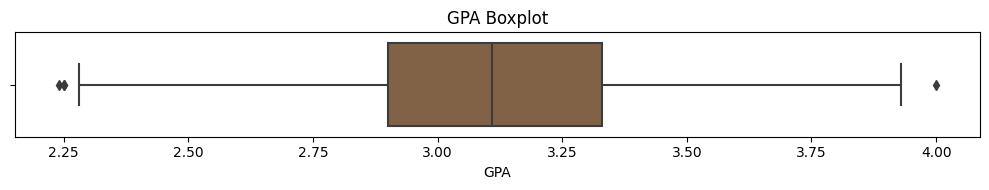


Summary Statistics for GPA:
 count    2000.000000
mean        3.115960
std         0.298674
min         2.240000
25%         2.900000
50%         3.110000
75%         3.330000
max         4.000000
Name: GPA, dtype: float64


In [11]:
# Function to perform univariate analysis for numeric columns
def univariate_analysis(data, column, title):
    plt.figure(figsize=(10, 2))
    
    # Define a muted color palette
    color = sns.color_palette("muted")[columns_to_analyze.index(column)]
    
    sns.boxplot(x=data[column], color=color)
    plt.title(f'{title} Boxplot')
    
    plt.tight_layout()
    plt.show()

    print(f'\nSummary Statistics for {title}:\n', data[column].describe())

# List of columns to analyze
columns_to_analyze = ['Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day', 
                       'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day', 
                       'Physical_Activity_Hours_Per_Day', 'GPA']

# Iterate through columns and perform univariate analysis
for column in columns_to_analyze:
    univariate_analysis(df, column, column.replace('_', ' '))

#### Insights

**1. Study Hours Per Day**
- **Range**: 5 to 10 hours.
- **Median**: 7.4 hours, close to the mean of 7.48 hours.
- **IQR (Interquartile Range)**: 6.3 to 8.7 hours.
- Outliers are minimal, indicating that most students follow a consistent study schedule.

**2. Extracurricular Hours Per Day**
- **Range**: 0 to 4 hours.
- **Median**: 2 hours, matching the mean of 1.99 hours.
- **IQR**: 1 to 3 hours.
- Outliers are rare, and most students engage in moderate extracurricular activities.

**3. Sleep Hours Per Day**
- **Range**: 5 to 10 hours.
- **Median**: 7.5 hours, equal to the mean of 7.50 hours.
- **IQR**: 6.2 to 8.8 hours.
- Outliers are minimal, suggesting consistent sleep patterns among students.

**4. Social Hours Per Day**
- **Range**: 0 to 6 hours.
- **Median**: 2.6 hours, slightly below the mean of 2.70 hours.
- **IQR**: 1.2 to 4.1 hours.
- Outliers exist at the lower and upper ends, indicating diverse social habits.

**5. Physical Activity Hours Per Day**
- **Range**: 0 to 13 hours.
- **Median**: 4.1 hours, close to the mean of 4.33 hours.
- **IQR**: 2.4 to 6.1 hours.
- Outliers are notable, with a few students reporting unusually high activity levels.

**6. GPA**
- **Range**: 2.24 to 4.0.
- **Median**: 3.11, near the mean of 3.12.
- **IQR**: 2.9 to 3.33.
- Outliers are rare, indicating most students have moderate to high academic performance.


### Key observations
- **Consistent Patterns**: Features like study hours, sleep hours, and GPA show limited outliers, suggesting uniformity in these behaviors.
- **Varied Engagement**: Social and physical activity hours display higher variability and outliers, highlighting different lifestyle choices among students.

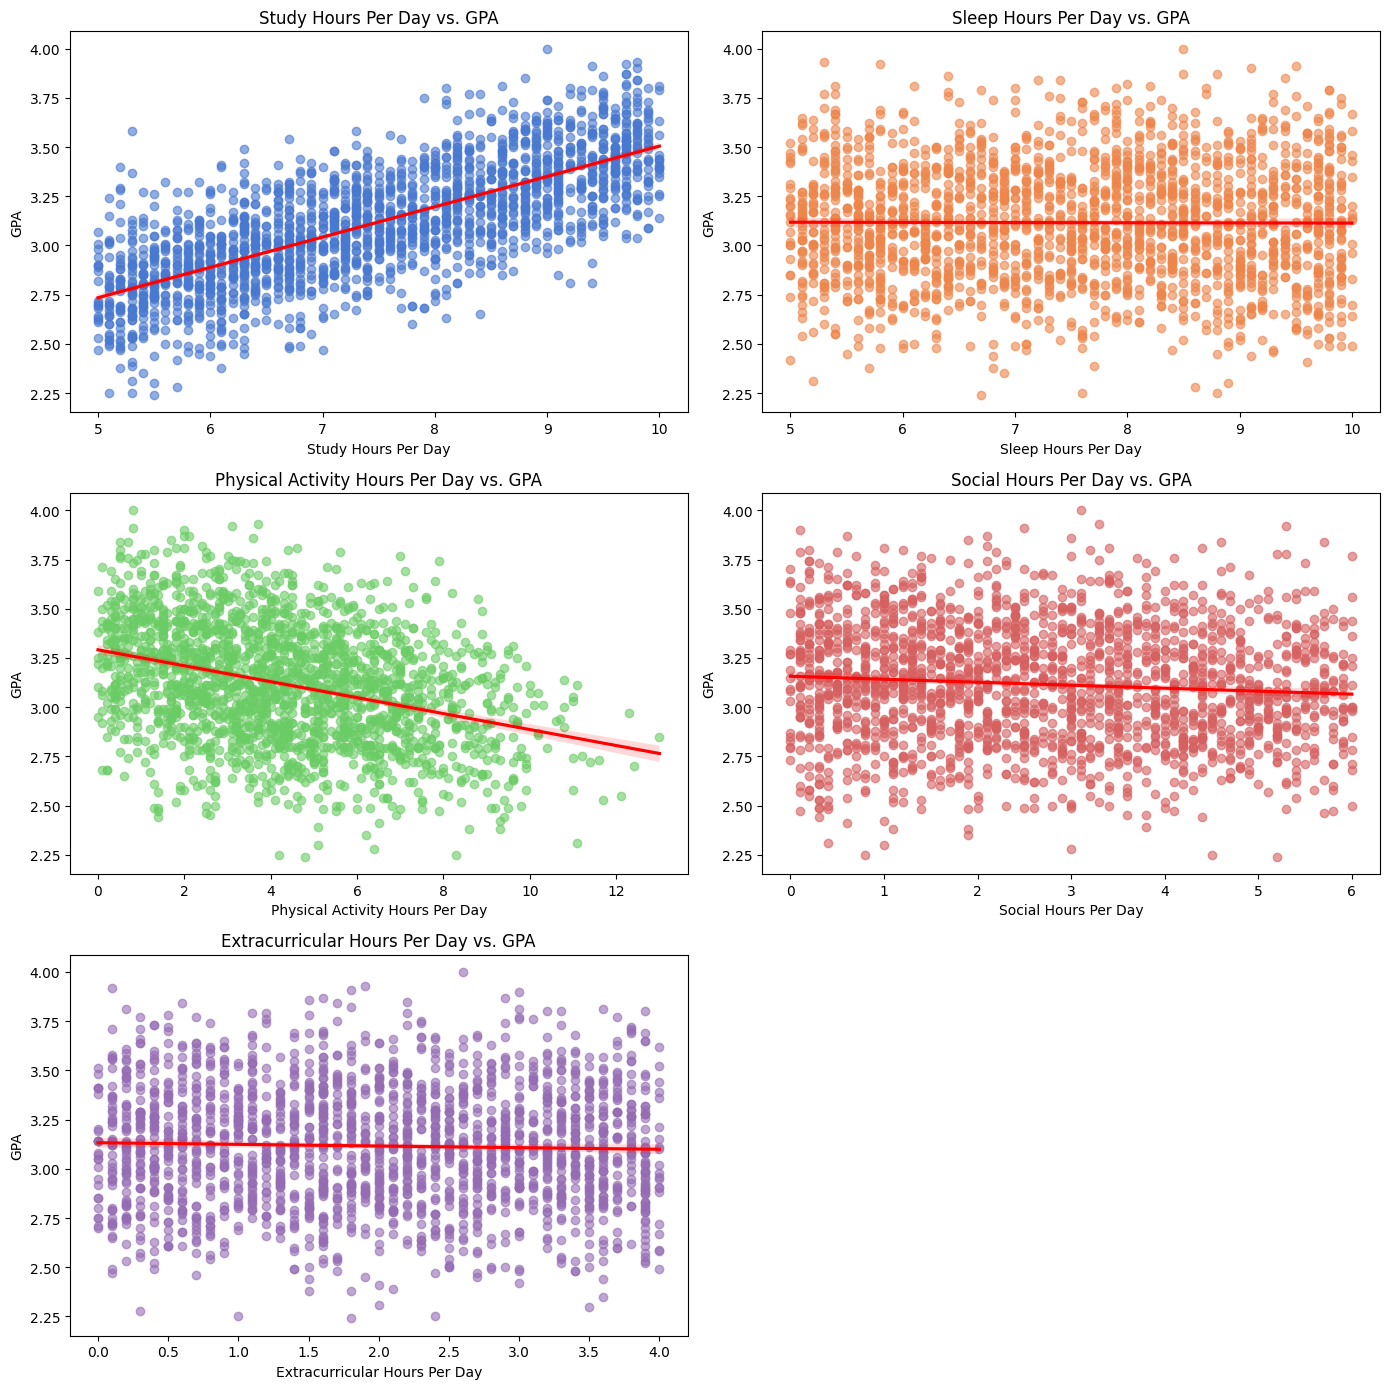

In [12]:
# Define muted colors from the palette
muted_colors = sns.color_palette("muted")

# Scatter plots with linear regression lines 
plt.figure(figsize=(14, 14))

# Study Hours vs. GPA
plt.subplot(3, 2, 1)
sns.regplot(x='Study_Hours_Per_Day', y='GPA', data=df,
            color=muted_colors[0], scatter_kws={'alpha':0.6}, line_kws={'color': 'red'})
plt.title('Study Hours Per Day vs. GPA')
plt.xlabel('Study Hours Per Day')
plt.ylabel('GPA')

# Sleep Hours vs. GPA
plt.subplot(3, 2, 2)
sns.regplot(x='Sleep_Hours_Per_Day', y='GPA', data=df,
            color=muted_colors[1], scatter_kws={'alpha':0.6}, line_kws={'color': 'red'})
plt.title('Sleep Hours Per Day vs. GPA')
plt.xlabel('Sleep Hours Per Day')
plt.ylabel('GPA')

# Physical Activity Hours vs. GPA
plt.subplot(3, 2, 3)
sns.regplot(x='Physical_Activity_Hours_Per_Day', y='GPA', data=df,
            color=muted_colors[2], scatter_kws={'alpha':0.6}, line_kws={'color': 'red'})
plt.title('Physical Activity Hours Per Day vs. GPA')
plt.xlabel('Physical Activity Hours Per Day')
plt.ylabel('GPA')

# Social Hours vs. GPA
plt.subplot(3, 2, 4)
sns.regplot(x='Social_Hours_Per_Day', y='GPA', data=df,
            color=muted_colors[3], scatter_kws={'alpha':0.6}, line_kws={'color': 'red'})
plt.title('Social Hours Per Day vs. GPA')
plt.xlabel('Social Hours Per Day')
plt.ylabel('GPA')

# Extracurricular Hours vs. GPA
plt.subplot(3, 2, 5)
sns.regplot(x='Extracurricular_Hours_Per_Day', y='GPA', data=df,
            color=muted_colors[4], scatter_kws={'alpha':0.6}, line_kws={'color': 'red'})
plt.title('Extracurricular Hours Per Day vs. GPA')
plt.xlabel('Extracurricular Hours Per Day')
plt.ylabel('GPA')

plt.tight_layout()
plt.show()


#### Insights with Linear Association 

1. **Study Hours Per Day vs. GPA**:
   - **Strong Positive Linear Relationship**:
     - The regression line clearly shows that as study hours increase, GPA also increases.
     - This validates that dedicating more time to studying significantly boosts academic performance.

2. **Sleep Hours Per Day vs. GPA**:
   - **No Significant Linear Relationship**:
     - The regression line is almost flat, indicating no meaningful correlation between sleep hours and GPA.
     - This suggests that variations in sleep do not directly impact GPA, as long as sleep is within a reasonable range.

3. **Physical Activity Hours Per Day vs. GPA**:
   - **Moderate Negative Linear Relationship**:
     - The regression line shows a slight downward trend, indicating that increased physical activity hours are associated with lower GPA.
     - This could imply a trade-off between physical activities and academic focus, though the effect is not drastic.

4. **Social Hours Per Day vs. GPA**:
   - **Weak Negative Linear Relationship**:
     - The regression line is slightly downward-sloping, suggesting a minimal negative impact of increased social hours on GPA.
     - Moderate socializing might not harm academic performance, but excessive social hours could potentially reduce GPA.
    
5. **Extracurricular Hours Per Day vs. GPAA**:
   - **No Significant Linear Relationship**:
     - The regression line is flat, indicating no correlation between extracurricular hours and GPA.
     - Engaging in extracurricular activities doesn't directly influence academic performance.

#### Overall Observations:
- **Study Hours are Crucial**: They exhibit the strongest positive correlation with GPA.
- **Balanced Lifestyle**: While physical and social activities show slight negative impacts on GPA, they are important for overall well-being.
- **Sleep is Neutral**: Sleep hours do not significantly influence GPA, as long as students get adequate rest.

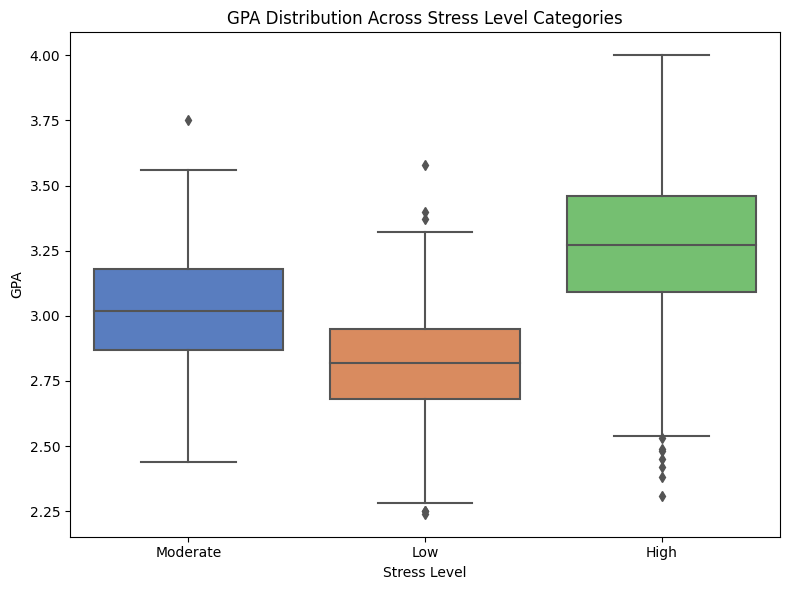

In [13]:
# Boxplot for GPA across different Stress_Level categories
plt.figure(figsize=(8, 6))
sns.boxplot(x='Stress_Level', y='GPA', data=df, palette='muted')

plt.title('GPA Distribution Across Stress Level Categories')
plt.xlabel('Stress Level')
plt.ylabel('GPA')

# Display the plot
plt.tight_layout()
plt.show()


#### Insights from GPA Across Stress Level Categories

1. **Low Stress**:
   - **Median GPA** is slightly lower compared to other stress levels.
   - **Spread**: The GPA distribution is more concentrated, with a narrower interquartile range (IQR).
   - **Key Insight**: Students with low stress may not always achieve the highest GPAs, possibly due to underutilizing their time.

2. **Moderate Stress**:
   - **Median GPA** is slightly higher compared to low stress, indicating better academic performance for students under moderate stress.
   - **Spread**: The IQR is wider, suggesting diverse academic performance within this group.
   - **Key Insight**: Moderate stress levels seem optimal for balancing productivity and performance.

3. **High Stress**:
   - **Median GPA** is the highest among all stress levels, indicating that some students under high stress still manage excellent academic performance.
   - **Spread**: The widest IQR, with a higher ceiling for GPA but also more variability.
   - **Key Insight**: While high stress can drive academic success for some, it may negatively impact others, as evidenced by outliers with lower GPAs.

#### Key observations:
1. **Moderate Stress**:
   - Often leads to stable and above-average GPA, indicating it may be the optimal stress level for balancing academic demands.
2. **High Stress**:
   - A double-edged sword: it can push some students to excel while significantly hindering others.
3. **Low Stress**:
   - Consistently lower median GPA suggests that minimal pressure might not motivate students enough to achieve peak academic performance.

This plot highlights the need for balance in stress levels to achieve optimal academic outcomes.


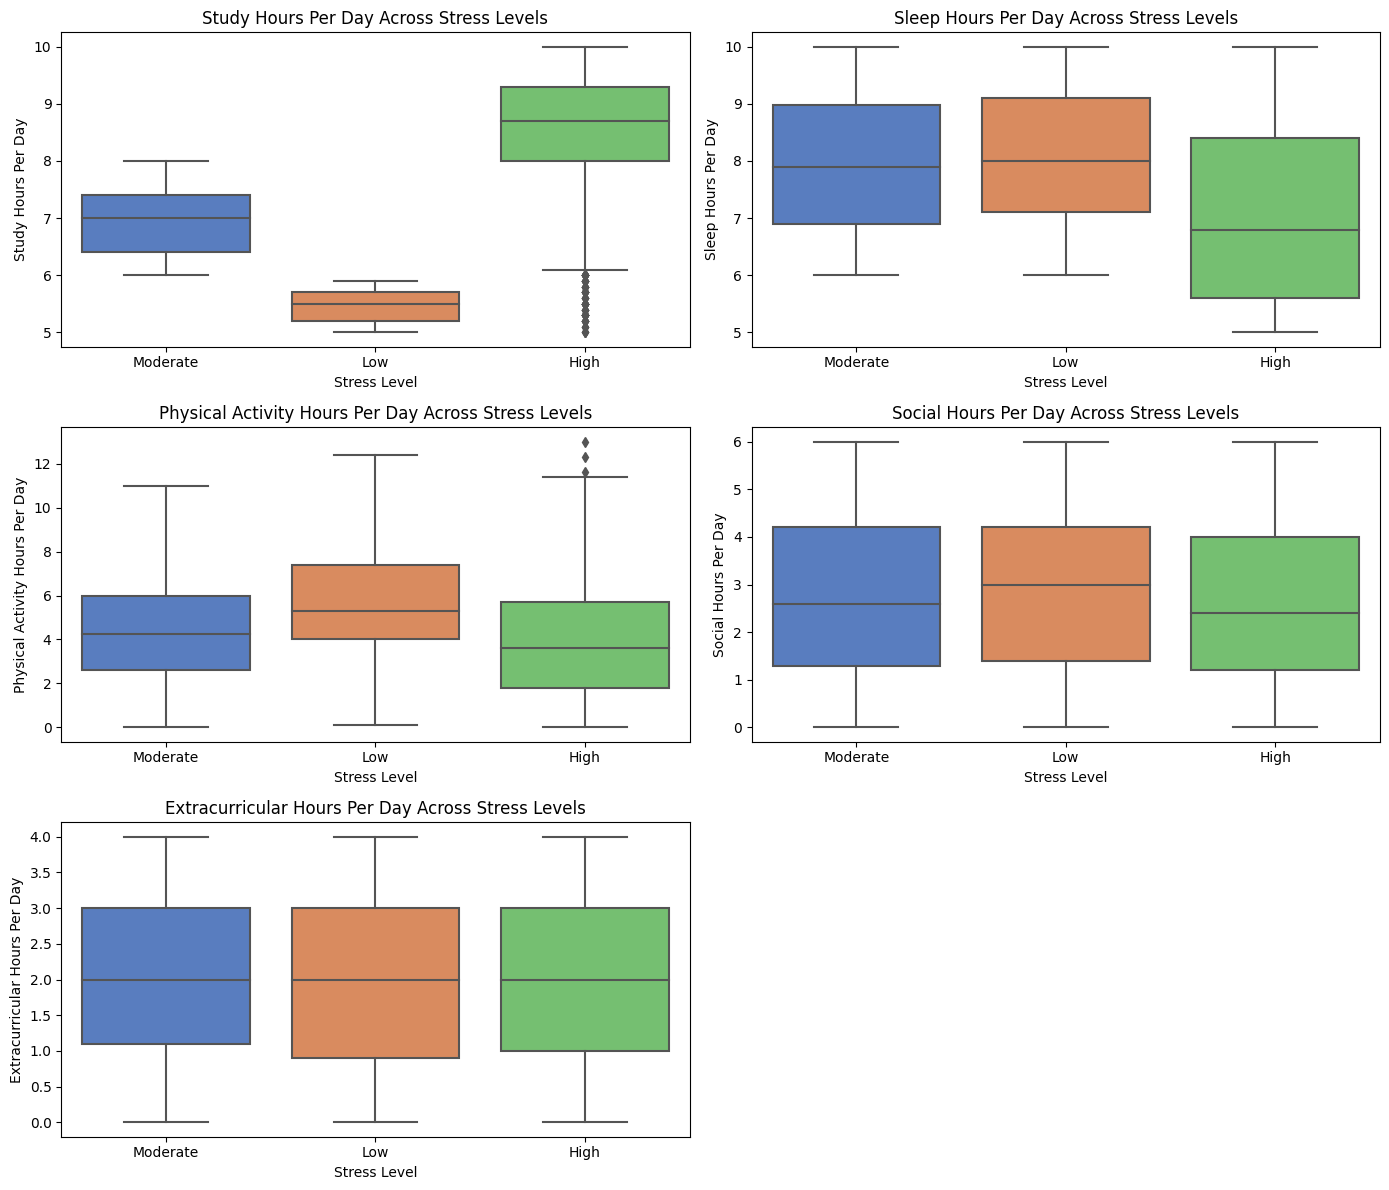

In [14]:
numerical_features = [
    'Study_Hours_Per_Day', 
    'Sleep_Hours_Per_Day', 
    'Physical_Activity_Hours_Per_Day', 
    'Social_Hours_Per_Day', 
    'Extracurricular_Hours_Per_Day'
]

# Create boxplots for each numerical feature grouped by Stress_Level
plt.figure(figsize=(14, 12))

for i, feature in enumerate(numerical_features, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(x='Stress_Level', y=feature, data=df, palette='muted')
    plt.title(f'{feature.replace("_", " ")} Across Stress Levels')
    plt.xlabel('Stress Level')
    plt.ylabel(feature.replace("_", " "))

plt.tight_layout()
plt.show()


#### Insights

1. **Study Hours Per Day**
	- **High Stress**: Students in this category have the highest median study hours and a wider range, indicating they dedicate more time to academics, likely contributing to their stress.
	- **Moderate Stress**: Median study hours are lower compared to high stress but still substantial.
	- **Low Stress**: Students in this group have the lowest median study hours, which may reflect a more relaxed approach to academics.

2. **Sleep Hours Per Day**
	- **High Stress**: This group has a slightly higher median sleep duration, but the range is consistent across all stress levels.
	- **Moderate and Low Stress**: Median sleep hours are very similar, suggesting sleep habits are not significantly affected by stress levels.

3. **Physical Activity Hours Per Day**
	- **Moderate and Low Stress**: Students in these groups engage in more physical activity on average, possibly as a way to manage stress.
	- **High Stress**: Median physical activity is lower, with fewer students engaging in extensive exercise, likely due to time constraints from academic pressures.

4. **Social Hours Per Day**
	- The median and range of social hours are similar across all stress levels.
	- Socializing doesn't seem to significantly vary with stress levels, indicating students maintain consistent social interactions regardless of stress.

5. **Extracurricular Hours Per Day**
	- Similar to social hours, extracurricular activities have consistent medians and ranges across all stress levels.
	- Students' engagement in extracurriculars is not strongly influenced by their stress level.

#### Key Observations:
1. **Study Hours**: Strongly linked to stress levels; high study hours correlate with higher stress.
2. **Physical Activity**: More common among low- and moderate-stress students; high-stress students may prioritize academics over exercise.
3. **Sleep and Socializing**: Show minimal variation across stress levels, suggesting they are less impacted by stress.
4. **Extracurricular Activities**: Uniformly distributed, indicating that stress doesn't heavily influence participation.

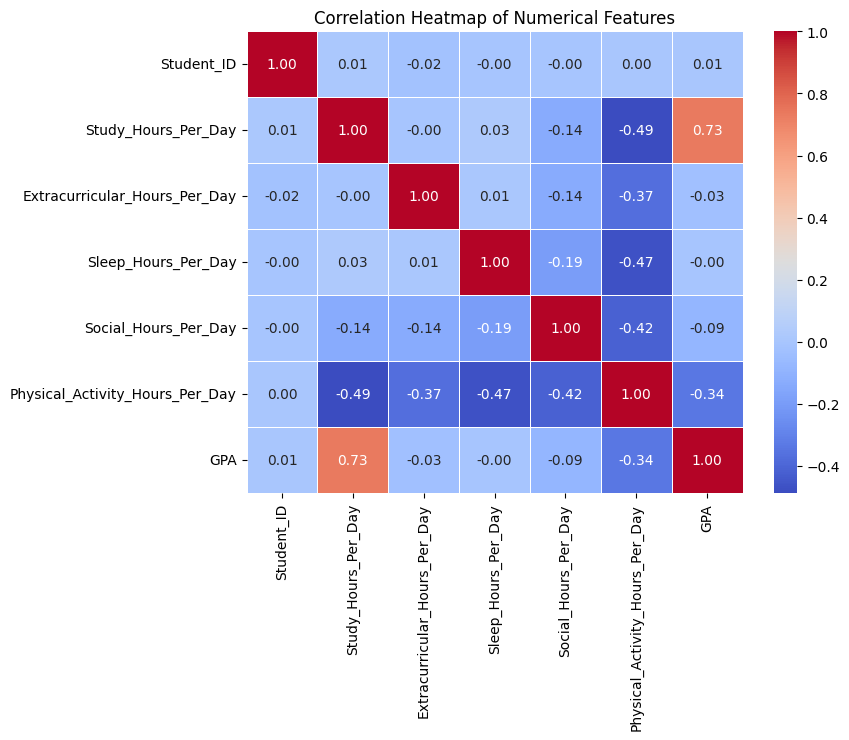

In [15]:
# Plotting a correlation heatmap for numerical variables
plt.figure(figsize=(8, 6))
numerical_columns = df.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numerical_columns.corr()

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

### Observational Insights from the Correlation Heatmap

#### **Key Correlations**:
1. **Study Hours and GPA**:
   - Strong positive correlation (**0.73**).
   - Indicates that students who study more tend to achieve higher GPAs, emphasizing the importance of study time in academic performance.

2. **Physical Activity and Study Hours**:
   - Moderate negative correlation (**-0.49**).
   - Suggests that students who spend more time on physical activities tend to study less, potentially due to time constraints.

3. **Physical Activity and GPA**:
   - Moderate negative correlation (**-0.34**).
   - Indicates that higher physical activity hours might be linked to slightly lower GPAs, possibly due to reduced study time.

4. **Social Hours and GPA**:
   - Weak negative correlation (**-0.09**).
   - Suggests minimal impact of socializing on academic performance, though excessive social hours could slightly hinder GPA.

5. **Extracurricular Hours and GPA**:
   - Virtually no correlation (**-0.03**).
   - Extracurricular activities appear to have negligible direct influence on academic performance.

6. **Sleep Hours and GPA**:
   - No meaningful correlation (**0.00**).
   - Suggests that sleep duration does not directly impact GPA, but its indirect effects (e.g., better focus) may still matter.

#### **Overall Observations**:
- **Study Hours** are the most impactful variable for GPA, with a strong positive relationship.
- **Physical Activity** has a moderate trade-off with study hours and GPA, highlighting the need for a balanced routine.
- **Social Hours and Extracurricular Hours** have minimal direct effect on GPA but could influence stress and overall well-being.

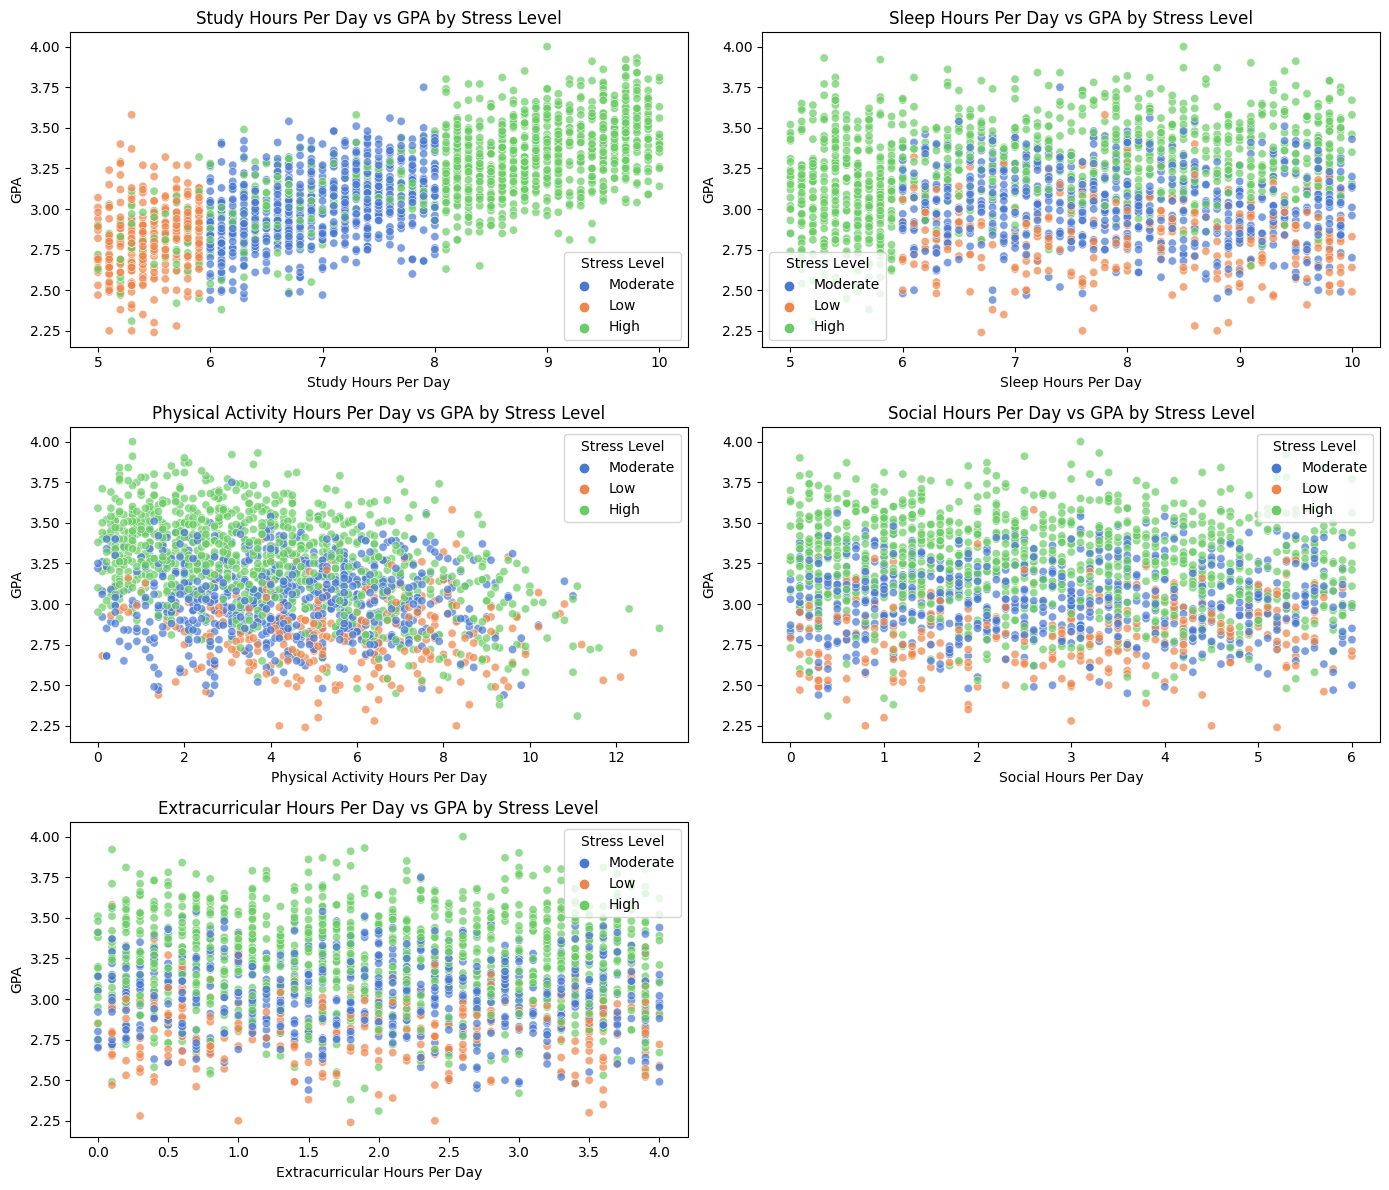

In [16]:
# Numerical features against GPA, grouped by Stress_Level
plt.figure(figsize=(14, 12))

numerical_features = [
    'Study_Hours_Per_Day', 
    'Sleep_Hours_Per_Day', 
    'Physical_Activity_Hours_Per_Day', 
    'Social_Hours_Per_Day', 
    'Extracurricular_Hours_Per_Day'
]

# Plot each feature
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(3, 2, i)
    sns.scatterplot(
        x=feature, 
        y='GPA', 
        hue='Stress_Level', 
        data=df, 
        palette='muted', 
        alpha=0.7
    )
    plt.title(f'{feature.replace("_", " ")} vs GPA by Stress Level')
    plt.xlabel(feature.replace('_', ' '))
    plt.ylabel('GPA')
    plt.legend(title='Stress Level')

plt.tight_layout()
plt.show()


#### Insights from Numerical Variables vs. GPA Grouped by Stress Level

1. **Study Hours Per Day vs. GPA by Stress Level**
   - **High Stress**:
     - Students with high study hours and high stress levels tend to achieve higher GPAs.
   - **Moderate Stress**:
     - Students with moderate stress levels and reasonable study hours show a wide range of GPAs, suggesting balance is crucial.
   - **Low Stress**:
     - Students with lower stress tend to have moderate GPAs regardless of study hours.

2. **Sleep Hours Per Day vs. GPA by Stress Level**
   - Across all stress levels, there is **no clear trend** between sleep hours and GPA.
   - Students with high GPAs are distributed evenly across various sleep durations, regardless of their stress levels.
   - **Key Insight**: Sleep duration does not significantly vary with stress level when it comes to academic performance.

3. **Physical Activity Hours Per Day vs. GPA by Stress Level**
   - **High Stress**:
     - Students with high stress tend to engage in less physical activity, and those who do have varied GPAs.
   - **Moderate Stress**:
     - A diverse range of GPAs is observed, with moderate activity levels associated with decent GPAs.
   - **Low Stress**:
     - Students with higher physical activity hours show a wide range of GPAs, indicating that activity might not directly influence GPA for this group.

4. **Social Hours Per Day vs. GPA by Stress Level**
   - The scatter plot shows **no strong correlation** between social hours and GPA, regardless of stress level.
   - **High Stress**:
     - Students under high stress tend to have consistent GPA ranges, even with varying social hours.
   - **Moderate Stress**:
     - Social hours vary widely, but GPAs remain distributed evenly.
   - **Low Stress**:
     - Similar trends are observed; social hours have minimal impact on GPA.

5. **Extracurricular Hours Per Day vs. GPA by Stress Level**
   - Across all stress levels, **no clear relationship** is observed between extracurricular hours and GPA.
   - Students engaging in 0–4 hours of extracurricular activities maintain varied GPAs, suggesting these activities do not direct
ensively, but for others, it might hinder performance.

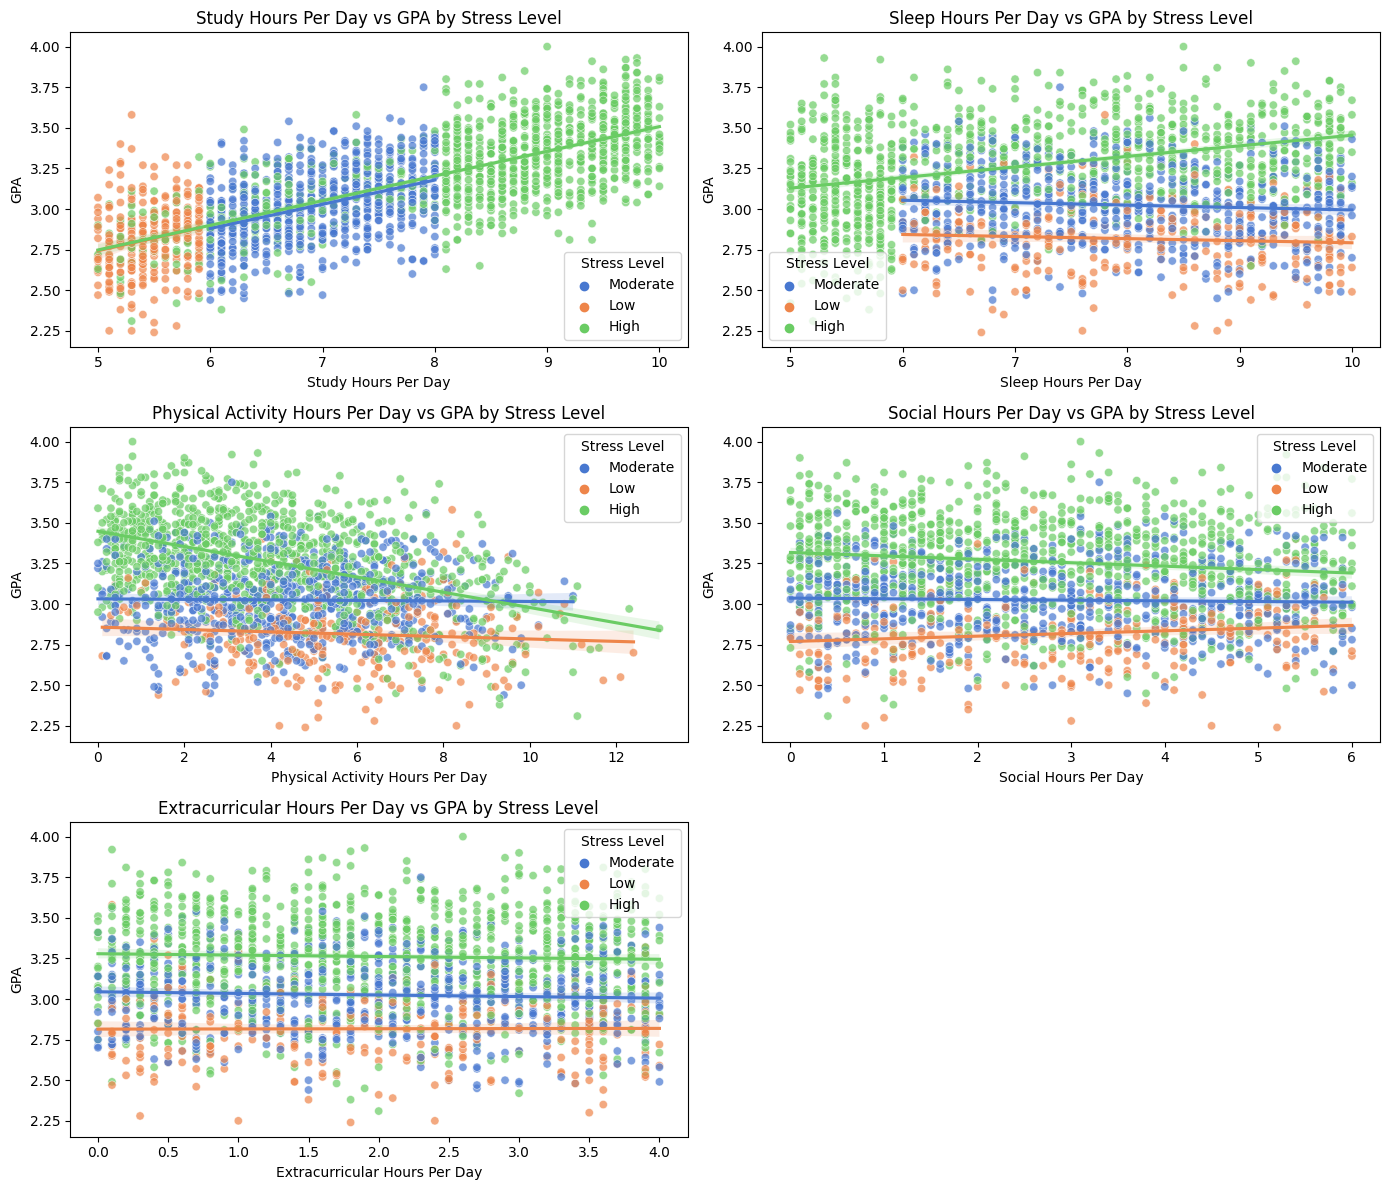

In [17]:
plt.figure(figsize=(14, 12))

numerical_features = [
    'Study_Hours_Per_Day', 
    'Sleep_Hours_Per_Day', 
    'Physical_Activity_Hours_Per_Day', 
    'Social_Hours_Per_Day', 
    'Extracurricular_Hours_Per_Day'
]

# Define colors for different stress levels
stress_colors = sns.color_palette('muted')

# Plot each feature
for i, feature in enumerate(numerical_features):
    plt.subplot(3, 2, i + 1)
    
    # Scatter plot with matching colors for stress levels
    sns.scatterplot(
        x=feature,
        y='GPA',
        hue='Stress_Level',
        data=df,
        palette=stress_colors,
        alpha=0.7
    )
    
    # Add linear regression lines for each stress level with matching colors
    for j, stress_level in enumerate(df['Stress_Level'].unique()):
        sns.regplot(
            x=feature,
            y='GPA',
            data=df[df['Stress_Level'] == stress_level],
            scatter=False,
            color=stress_colors[j], # Use the same color for the line as in the scatter plot
            line_kws={'label': stress_level}
        )
    
    plt.title(f'{feature.replace("_", " ")} vs GPA by Stress Level')
    plt.xlabel(feature.replace('_', ' '))
    plt.ylabel('GPA')
    plt.legend(title='Stress Level')

plt.tight_layout()
plt.show()

### Insights from Scatter Plots with Linear Regression Lines:
1. **Study Hours**:
   - Strong positive correlation with GPA, especially for students under high and moderate stress.
2. **Physical Activity**:
   - High activity levels may slightly reduce GPA for high-stress students.
3. **Sleep, Social, and Extracurricular Hours**:
   - Minimal impact on GPA across all stress levels, highlighting their indirect role in academic outcomes.
4. **Stress Levels**:
   - High stress intensifies the relationship between study hours and GPA, while low stress weakens it.

In [18]:
# Define thresholds for low and high GPA
low_gpa_threshold = 2.5
high_gpa_threshold = 3.5  

# Filter students with low GPA (less than or equal to the threshold)
low_gpa_students = df[df['GPA'] <= low_gpa_threshold][
    ['GPA', 'Study_Hours_Per_Day', 'Physical_Activity_Hours_Per_Day', 'Stress_Level']
]

# Display results in a clear format
print("----- Students with Low GPA (<= 2.5) -----")
display(low_gpa_students)

# Filter students with high GPA (equal to the threshold)
high_gpa_students = df[df['GPA'] >= high_gpa_threshold][
    ['GPA', 'Study_Hours_Per_Day', 'Physical_Activity_Hours_Per_Day', 'Stress_Level']
]

# Display results in a clear format
print("\n----- Students with High GPA (>= 3.5) -----")
display(high_gpa_students)


----- Students with Low GPA (<= 2.5) -----


,GPA,Study_Hours_Per_Day,Physical_Activity_Hours_Per_Day,Stress_Level
32,2.47,5.2,7.9,Low
56,2.39,5.3,5.1,Low
134,2.45,6.3,2.6,Moderate
158,2.38,6.1,9.3,High
165,2.46,5.8,2.5,Low
283,2.50,6.2,9.8,Moderate
331,2.25,5.1,8.3,Low
377,2.28,5.7,6.4,Low
382,2.31,5.3,11.1,High
504,2.49,5.2,4.6,Low



----- Students with High GPA (>= 3.5) -----


,GPA,Study_Hours_Per_Day,Physical_Activity_Hours_Per_Day,Stress_Level
4,3.51,8.1,6.6,High
34,3.62,9.7,6.3,High
45,3.55,9.7,0.6,High
51,4.00,9.0,0.8,High
60,3.67,8.3,1.3,High
...,...,...,...,...
1939,3.52,8.1,2.4,High
1962,3.59,9.4,2.9,High
1964,3.54,9.9,3.0,High
1987,3.86,9.5,3.6,High


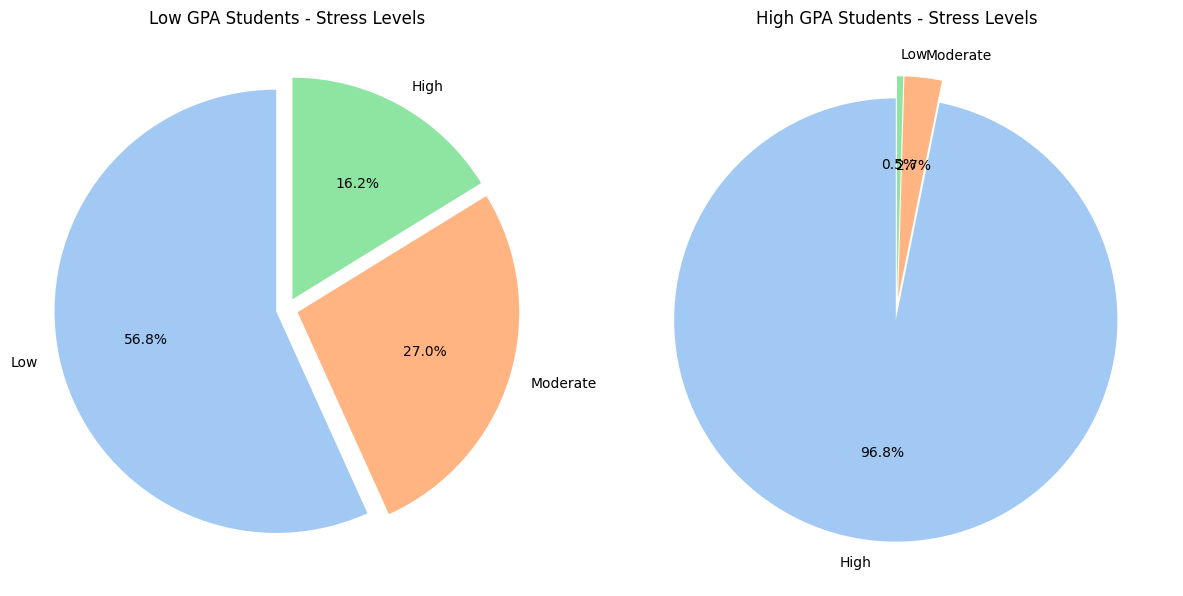

In [19]:
# Prepare data for low GPA students' stress levels
low_gpa_stress_counts = low_gpa_students['Stress_Level'].value_counts()

# Prepare data for high GPA students' stress levels
high_gpa_stress_counts = high_gpa_students['Stress_Level'].value_counts()

# Create subplots for pie charts
plt.figure(figsize=(12, 6))

# Low GPA students' stress levels pie chart
plt.subplot(1, 2, 1)
low_gpa_stress_counts.plot.pie(
    autopct='%1.1f%%', 
    colors=sns.color_palette('pastel'), 
    startangle=90, 
    explode=[0.05] * len(low_gpa_stress_counts), 
    labels=low_gpa_stress_counts.index
)
plt.title('Low GPA Students - Stress Levels')
plt.ylabel('')  

# High GPA students' stress levels pie chart
plt.subplot(1, 2, 2)
high_gpa_stress_counts.plot.pie(
    autopct='%1.1f%%', 
    colors=sns.color_palette('pastel'), 
    startangle=90, 
    explode=[0.05] * len(high_gpa_stress_counts), 
    labels=high_gpa_stress_counts.index
)
plt.title('High GPA Students - Stress Levels')
plt.ylabel('')  

# Show the plots
plt.tight_layout()
plt.show()


#### Insights from the Stress Levels of Low and High GPA Students

**Low GPA Students**
- **Low Stress**: 56.8% of low GPA students experience low stress levels, suggesting a potential lack of motivation or pressure to perform academically.
- **Moderate Stress**: 27.0% of low GPA students have moderate stress levels.
- **High Stress**: 16.2% of low GPA students experience high stress, indicating that excessive stress may negatively impact academic performance for some.

**High GPA Students**
- **High Stress**: A striking 96.8% of high GPA students experience high stress, implying that high levels of stress may drive academic excellence for most of these students.
- **Moderate Stress**: Only 2.7% of high GPA students report moderate stress levels.
- **Low Stress**: A negligible 0.5% of high GPA students report low stress, suggesting that minimal stress is not conducive to achieving top academic performance.

#### Key observation
1. **Stress and GPA Relationship**:
   - High stress is overwhelmingly prevalent among high GPA students, indicating its role as a potential driver for academic success.
   - Low stress dominates among low GPA students, reflecting a lack of academic pressure or urgency.

2. **Moderate Stress as a Balance**:
   - Moderate stress levels are more balanced between the two groups, showing it might support stable performance but isn't as common among top performers.

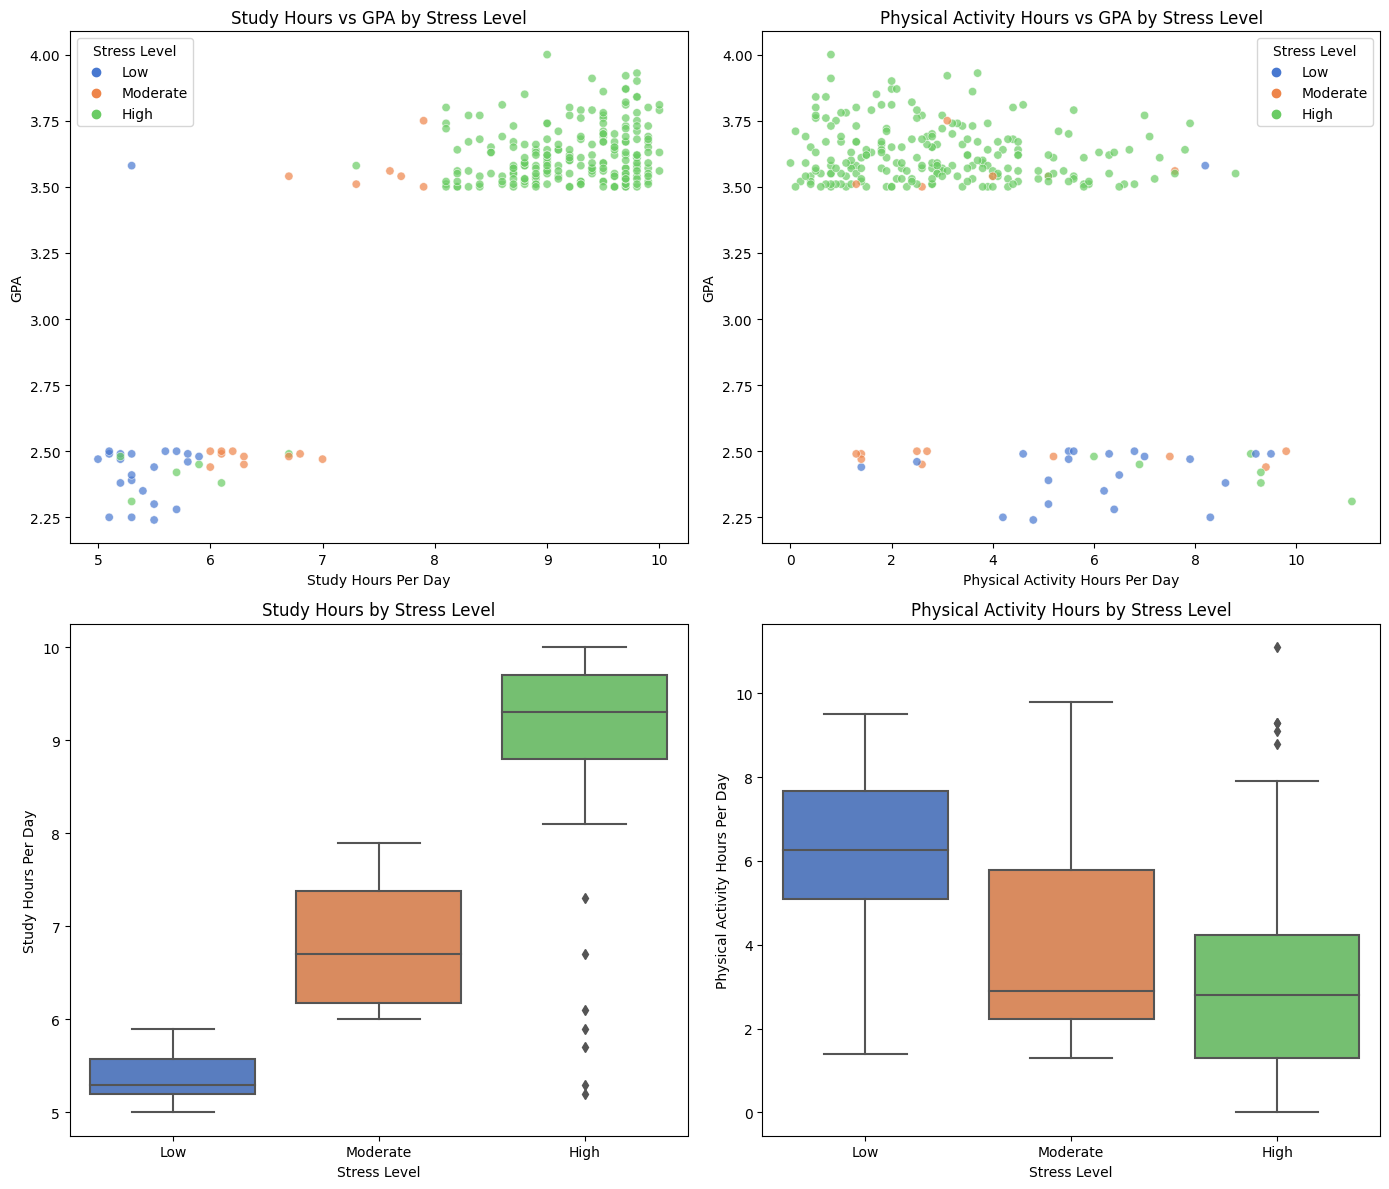

In [20]:
# Combine low and high GPA students for comparison
low_high_gpa_comparison = pd.concat([low_gpa_students, high_gpa_students])

# Create scatter plots to compare study hours and physical activity hours with stress level and GPA
plt.figure(figsize=(14, 12))

# Study Hours vs GPA
plt.subplot(2, 2, 1)
sns.scatterplot(
    x='Study_Hours_Per_Day', 
    y='GPA', 
    hue='Stress_Level', 
    data=low_high_gpa_comparison, 
    palette='muted', 
    alpha=0.7
)
plt.title('Study Hours vs GPA by Stress Level')
plt.xlabel('Study Hours Per Day')
plt.ylabel('GPA')
plt.legend(title='Stress Level')

# Physical Activity Hours vs GPA
plt.subplot(2, 2, 2)
sns.scatterplot(
    x='Physical_Activity_Hours_Per_Day', 
    y='GPA', 
    hue='Stress_Level', 
    data=low_high_gpa_comparison, 
    palette='muted', 
    alpha=0.7
)
plt.title('Physical Activity Hours vs GPA by Stress Level')
plt.xlabel('Physical Activity Hours Per Day')
plt.ylabel('GPA')
plt.legend(title='Stress Level')

# Study Hours vs Stress Level
plt.subplot(2, 2, 3)
sns.boxplot(
    x='Stress_Level', 
    y='Study_Hours_Per_Day', 
    data=low_high_gpa_comparison, 
    palette='muted'
)
plt.title('Study Hours by Stress Level')
plt.xlabel('Stress Level')
plt.ylabel('Study Hours Per Day')

# Physical Activity Hours vs Stress Level
plt.subplot(2, 2, 4)
sns.boxplot(
    x='Stress_Level', 
    y='Physical_Activity_Hours_Per_Day', 
    data=low_high_gpa_comparison, 
    palette='muted'
)
plt.title('Physical Activity Hours by Stress Level')
plt.xlabel('Stress Level')
plt.ylabel('Physical Activity Hours Per Day')

plt.tight_layout()
plt.show()

#### Insights from Comparison of Low and High GPA Students

1. **Study Hours vs. GPA by Stress Level**
	- **High Stress**: Students with high stress and extensive study hours tend to achieve higher GPAs, showcasing a positive relationship.
	- **Moderate and Low Stress**: These groups display a weaker relationship between study hours and GPA, with more variability in academic outcomes.

2. **Physical Activity Hours vs. GPA by Stress Level**
	- **High Stress**: Students engaging in limited physical activity tend to achieve higher GPAs, suggesting they might prioritize academics over exercise.
	- **Low and Moderate Stress**: More physical activity hours are observed in these groups, but the relationship with GPA is weak or slightly negative.

3. **Study Hours by Stress Level**
	- **High Stress**: Students in this group dedicate the most time to studying, with a broader range of hours.
	- **Moderate Stress**: A smaller range of study hours, suggesting less academic pressure.
	- **Low Stress**: The least time spent studying, reflecting a relaxed academic approach.

4. **Physical Activity Hours by Stress Level**
	- **Low and Moderate Stress**: Higher physical activity hours are observed in these groups, potentially as a way to balance stress.
	- **High Stress**: Students in this category engage in less physical activity, likely due to prioritizing study time.

#### Key observations
1. **Stress and Study Time**:
   - High stress is associated with more study hours and higher GPAs.
   - Low stress correlates with reduced study hours and lower GPAs.

2. **Physical Activity and Stress**:
   - Students with low or moderate stress levels engage more in physical activities, while high-stress students focus on academics.

In [21]:
# Identify the maximum and minimum GPA in the dataset
max_gpa = df['GPA'].max()
min_gpa = df['GPA'].min()

# Count the number of students with maximum and minimum GPA
num_students_max_gpa = df[df['GPA'] == max_gpa].shape[0]
num_students_min_gpa = df[df['GPA'] == min_gpa].shape[0]

max_gpa_info = {
    "Max GPA": max_gpa,
    "Number of Students with Max GPA": num_students_max_gpa
}

min_gpa_info = {
    "Min GPA": min_gpa,
    "Number of Students with Min GPA": num_students_min_gpa
}

print("--- GPA Summary Statistics ---\n")
print("Maximum GPA Information:")
for key, value in max_gpa_info.items():
    print(f"- {key}: {value}")

print("\nMinimum GPA Information:")
for key, value in min_gpa_info.items():
    print(f"- {key}: {value}")

--- GPA Summary Statistics ---

Maximum GPA Information:
- Max GPA: 4.0
- Number of Students with Max GPA: 1

Minimum GPA Information:
- Min GPA: 2.24
- Number of Students with Min GPA: 1


- This indicates that the highest and lowest GPA in the dataset are each achieved by a single student.

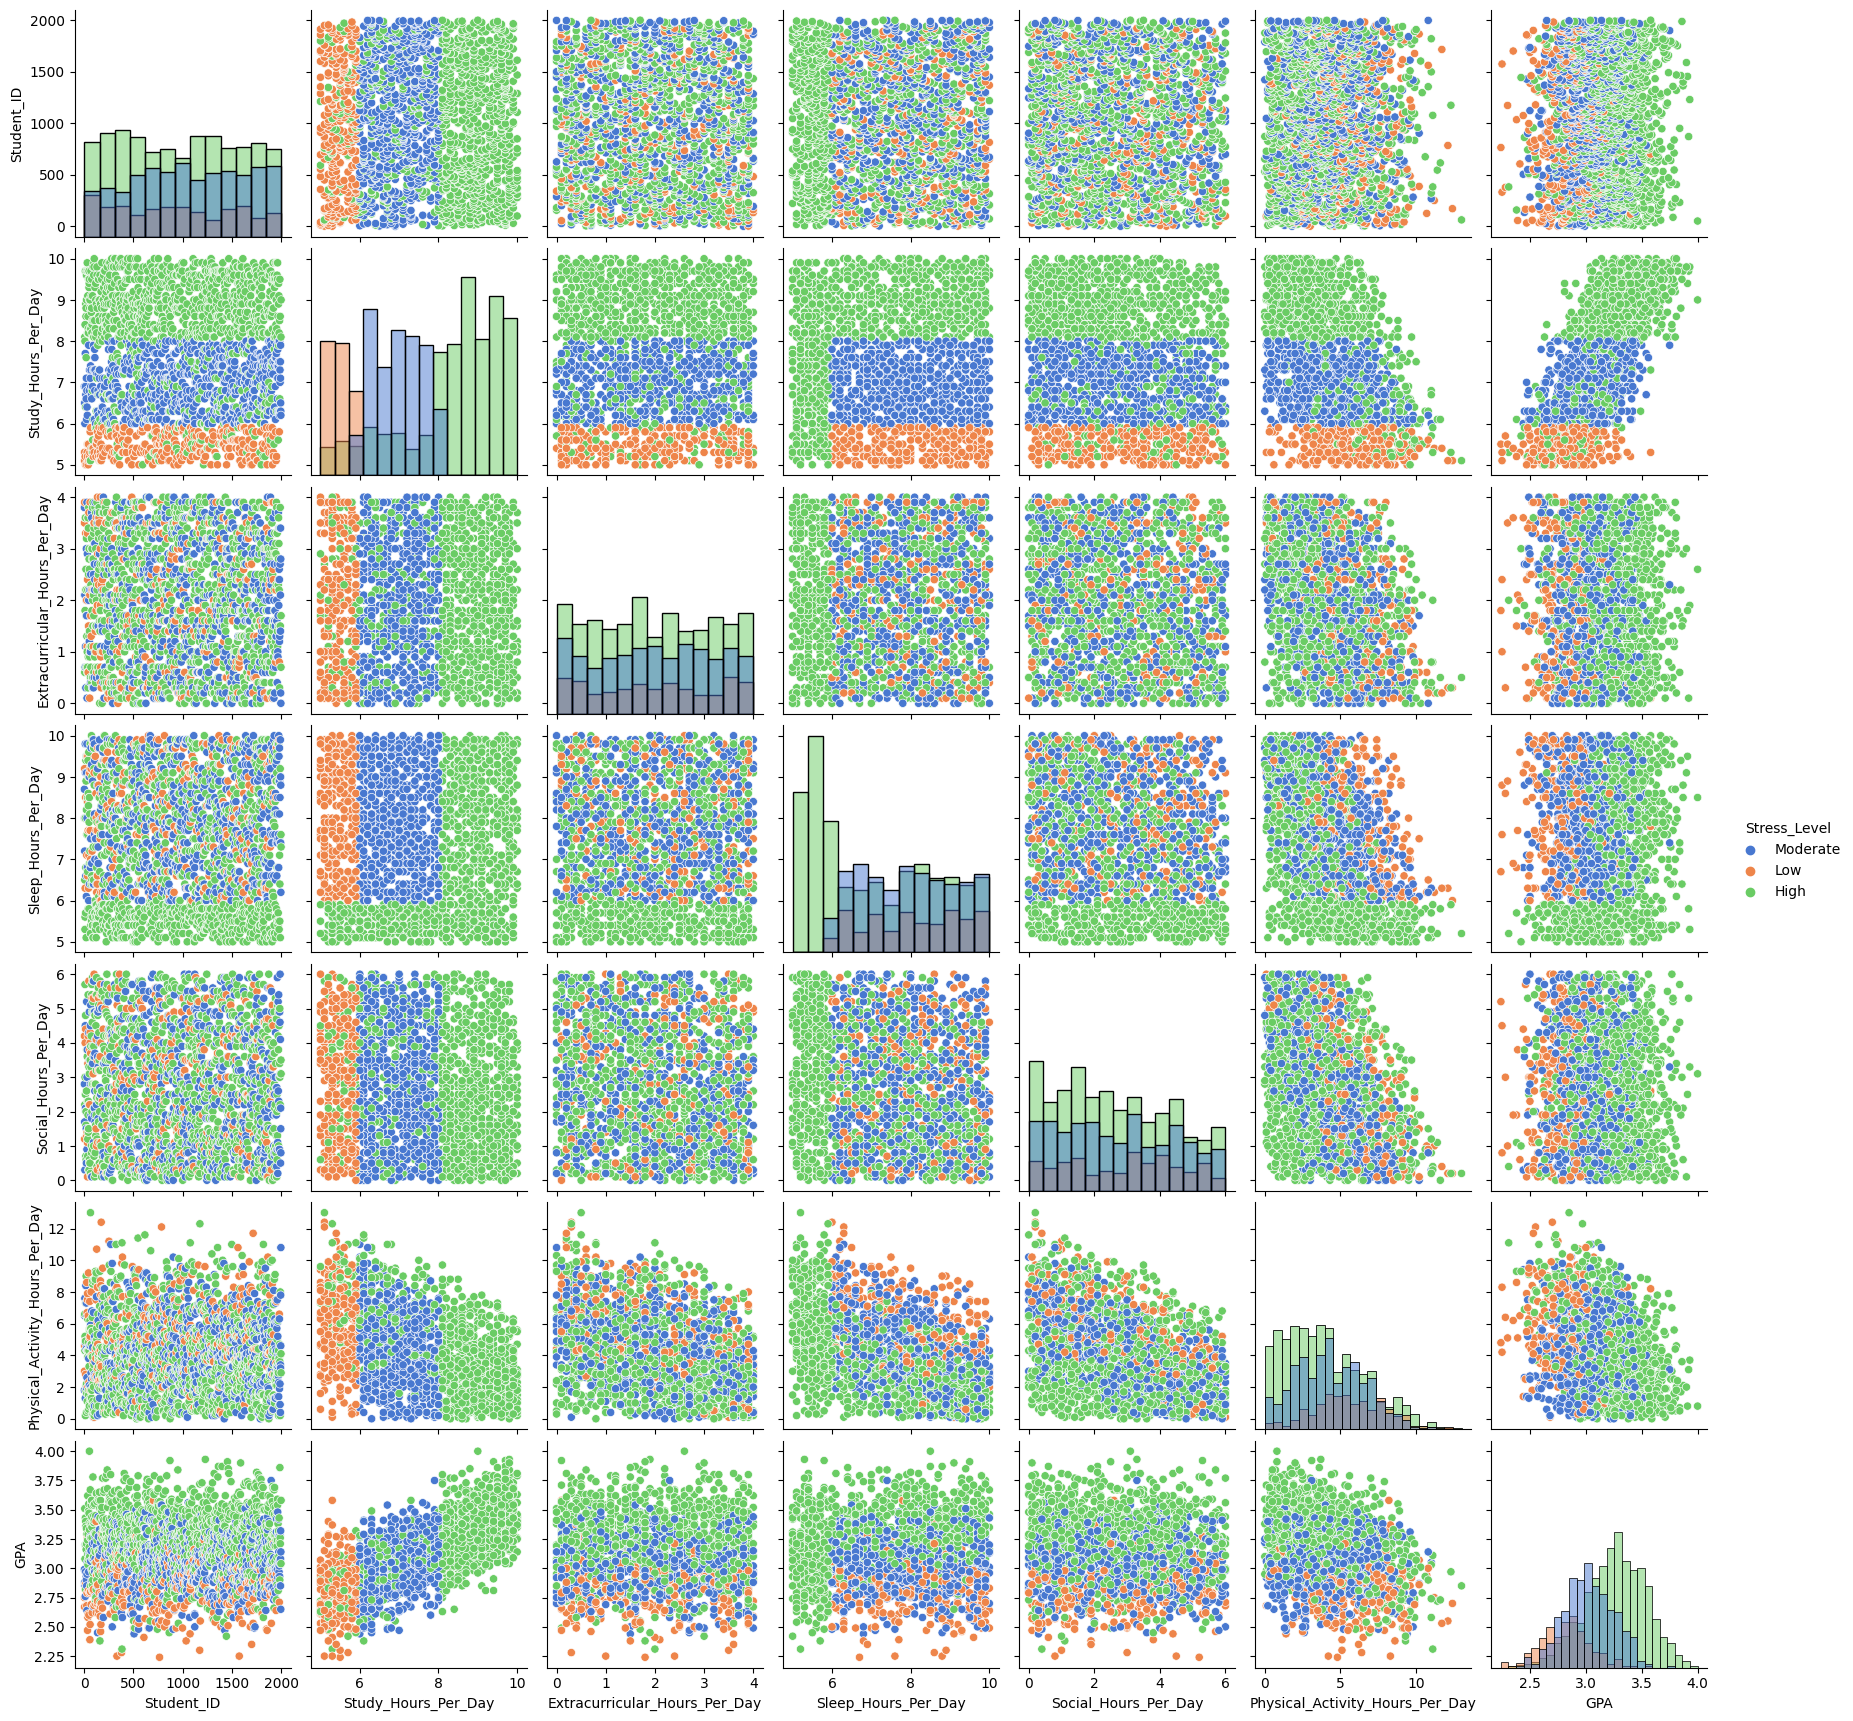

In [22]:
sns.pairplot(df, hue='Stress_Level', diag_kind='hist', palette='muted')

#### Insights from the PairPlot Visualization

**Stress-Level-Specific Observations**
1. **High Stress**:
   - High stress is associated with more study hours and higher GPAs.
   - Physical activity tends to decrease significantly for these students.

2. **Moderate Stress**:
   - A balance is evident between study hours, GPA, and physical activity.
   - This group maintains a moderate GPA range.

3. **Low Stress**:
   - Students in this group study less, engage more in physical activities, and tend to have lower GPAs.

#### Key Observations
- **High Stress Drives Academic Performance**:
   - Students with high stress focus heavily on studying, leading to better GPAs but reduced physical activity.
- **Moderate Stress Offers Balance**:
   - Students with moderate stress manage to balance academics and physical activity, achieving decent GPAs.
- **Low Stress and Less Academic Focus**:
   - Students with low stress prioritize physical activity over studying, which correlates with lower academic performance.

# <span style="color:transparent;">Data Preprocessing</span>

<div style="border-radius: 15px 0 15px 0px; border: 2px solid #f1c40f; padding: 10px; background-color: #191970; text-align: center; box-shadow: 0px 2px 4px rgba(0, 0, 0, 0.2);">
    <h1 style="color: #f1c40f; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px; font-size: 24px;">Data Preprocessing</h1>
</div>

## Creating New Features for Deeper Insights

In [23]:
# Define a function to categorize academic performance based on GPA
def categorize_academic_performance(gpa):
    if gpa >= 3.5:
        return 'Excellent'
    elif 3.0 <= gpa < 3.5:  
        return 'Good'
    elif 2.0 <= gpa < 3.0:  
        return 'Fair'
    else:
        return 'Poor'

# Apply the function to create a new column for academic performance
df['Academic_Performance'] = df['GPA'].apply(categorize_academic_performance)

# Display the counts of each category for verification
academic_performance_counts = df['Academic_Performance'].value_counts()

# Display the results
academic_performance_counts


Academic_Performance
Good         1067
Fair          712
Excellent     221
Name: count, dtype: int64

The **Academic Performance** feature has been successfully categorized with the following distribution:

- **Good (3.0 - 3.49)**: 1,067 students
- **Fair (2.0 - 2.99)**: 712 students
- **Excellent (3.5 - 4.0)**: 221 students
- **Poor (< 2.0)**: 0 students

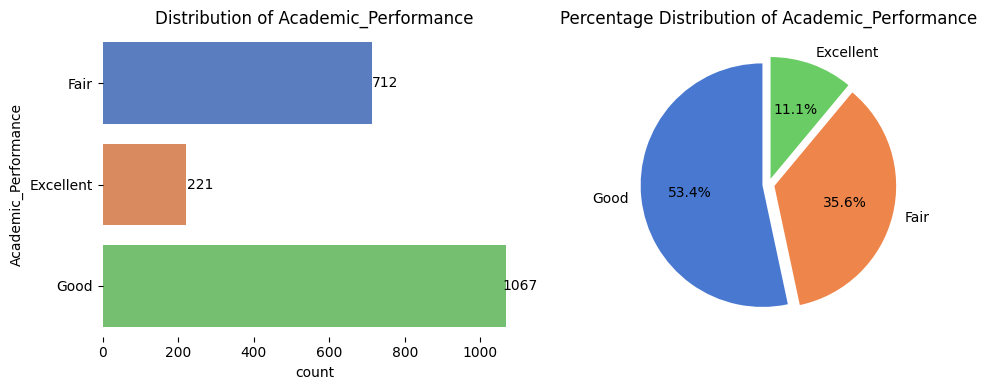

In [24]:
column_name = 'Academic_Performance'
plt.figure(figsize=(10, 4))

# First subplot: Count plot
plt.subplot(1, 2, 1)
sns.countplot(y=column_name, data=df, palette='muted')  
plt.title(f'Distribution of {column_name}')

ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}', (p.get_width(), p.get_y() + p.get_height() / 2), 
                ha='center', va='center', xytext=(10, 0), textcoords='offset points')

sns.despine(left=True, bottom=True)

# Second subplot: Pie chart
plt.subplot(1, 2, 2)
df[column_name].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('muted'), startangle=90, explode=[0.05]*df[column_name].nunique())
plt.title(f'Percentage Distribution of {column_name}')
plt.ylabel('')  

plt.tight_layout()
plt.show()

#### Insights from Academic Performance Distribution

   - **Good (53.4%)**: The majority of students fall under the "Good" academic performance category (GPA between 3.0 - 3.49).
   - **Fair (35.6%)**: A significant proportion of students have "Fair" academic performance (GPA between 2.0 - 2.99).
   - **Excellent (11.1%)**: Only a small percentage of students achieve "Excellent" academic performance (GPA between 3.5 - 4.0).
   - **Poor**: No students fall into the "Poor" category (GPA below 2.0) in this dataset.
   - The percentage distribution confirms that most students perform at a "Good" level, followed by "Fair."
   - The "Excellent" category is significantly smaller, indicating fewer students achieving top GPAs.

#### Key Observations
- The majority of students perform well academically but fall short of excellence.
- There is room for improvement in converting "Good" performers to "Excellent."



In [25]:
# Encoding Stress_Level and Academic_Performance with explicit ordinal mappings

# Mapping for Stress_Level (ordinal encoding)
mapping_stress = {'Low': 0, 'Moderate': 1, 'High': 2}
df['Stress_Level_Encoded'] = df['Stress_Level'].map(mapping_stress)

# Mapping for Academic_Performance (ordinal encoding)
mapping_performance = {'Poor': 0, 'Fair': 1, 'Good': 2, 'Excellent': 3}
df['Academic_Performance_Encoded'] = df['Academic_Performance'].map(mapping_performance)

# Display the first few rows of the dataset to verify the new columns
df[['Stress_Level', 'Stress_Level_Encoded', 'Academic_Performance', 'Academic_Performance_Encoded']].head(10)


,Stress_Level,Stress_Level_Encoded,Academic_Performance,Academic_Performance_Encoded
0,Moderate,1,Fair,1
1,Low,0,Fair,1
2,Low,0,Fair,1
3,Moderate,1,Fair,1
4,High,2,Excellent,3
5,Moderate,1,Fair,1
6,High,2,Good,2
7,High,2,Good,2
8,Low,0,Fair,1
9,Moderate,1,Fair,1


In [26]:
# Drop the original categorical columns
df = df.drop(columns=['Stress_Level', 'Academic_Performance'])

# Verify the updated dataset
df.head()


,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level_Encoded,Academic_Performance_Encoded
0,1,6.9,3.8,8.7,2.8,1.8,2.99,1,1
1,2,5.3,3.5,8.0,4.2,3.0,2.75,0,1
2,3,5.1,3.9,9.2,1.2,4.6,2.67,0,1
3,4,6.5,2.1,7.2,1.7,6.5,2.88,1,1
4,5,8.1,0.6,6.5,2.2,6.6,3.51,2,3


In [27]:
# Creating a table for correlation of the target variable 'Stress_Level_Encoded' with other features
target_variable = 'Stress_Level_Encoded'
target_correlation_table = df.corr()[[target_variable]].sort_values(by=target_variable, ascending=False)

# Displaying the table
target_correlation_table


,Stress_Level_Encoded
Stress_Level_Encoded,1.000000
Study_Hours_Per_Day,0.738843
GPA,0.550395
Academic_Performance_Encoded,0.504442
Student_ID,0.003306
Extracurricular_Hours_Per_Day,-0.006099
Social_Hours_Per_Day,-0.054702
Physical_Activity_Hours_Per_Day,-0.205207
Sleep_Hours_Per_Day,-0.298917


#### Insights from the Correlation Table (Target: Stress_Level_Encoded)

1. **Positive Correlations**:
   - **Study_Hours_Per_Day (0.738843)**:
     - The strongest positive correlation, indicating that students with higher stress levels tend to spend significantly more time studying.
   - **GPA (0.550395)**:
     - A moderate positive correlation, suggesting that higher stress levels are associated with higher academic performance.
   - **Academic_Performance_Encoded (0.504442)**:
     - Positive correlation shows that students with higher stress levels often fall into higher academic performance categories (Good, Excellent).

2. **Weak Positive Correlation**:
   - **Student_ID (0.003306)**:
     - Negligible correlation, as expected, since Student_ID is not related to stress levels.

3. **Negative Correlations**:
   - **Sleep_Hours_Per_Day (-0.298917)**:
     - A moderate negative correlation, indicating that higher stress levels are linked to reduced sleep duration.
   - **Physical_Activity_Hours_Per_Day (-0.205207)**:
     - Negative correlation suggests that students with higher stress levels engage in less physical activity.
   - **Social_Hours_Per_Day (-0.054702)**:
     - Weak negative correlation implies a slight tendency for high-stress students to spend less time socializing.
   - **Extracurricular_Hours_Per_Day (-0.006099)**:
     - Very weak negative correlation, showing minimal impact of extracurricular activities on stress levels.

In [28]:
# Define the features (X) and the target variable (y)
X = df.drop(columns=['Student_ID', 'Stress_Level_Encoded'])  
y = df['Stress_Level_Encoded']  

# Display shapes to confirm the split
print("X Shape:", X.shape)
print("\ny Shape:", y.shape)

X Shape: (2000, 7)

y Shape: (2000,)


In [29]:
# Outlier detection using Isolation Forest
iso_forest = IsolationForest(contamination=0.01, random_state=42)
outlier_predictions = iso_forest.fit_predict(X)

# Identify outliers: Isolation Forest marks outliers as -1
outlier_indices = X.index[outlier_predictions == -1]

# Print the number of outliers detected
print(f"Number of detected outliers: {len(outlier_indices)}")

Number of detected outliers: 20


In [30]:
# Remove outliers
X_filtered = X.drop(outlier_indices, axis=0).reset_index(drop=True)
y_filtered = y.drop(outlier_indices, axis=0).reset_index(drop=True)

print(f"New shape of X after removing outliers: {X_filtered.shape}")
print(f"New shape of y after removing outliers: {y_filtered.shape}")

New shape of X after removing outliers: (1980, 7)
New shape of y after removing outliers: (1980,)


In [31]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y_filtered, test_size=0.2, random_state=42)

# Display the shapes of the splits for verification
print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)


X_train Shape: (1584, 7)
X_test Shape: (396, 7)
y_train Shape: (1584,)
y_test Shape: (396,)


In [32]:
# Apply RobustScaler
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# <span style="color:transparent;">Model Training and Evaluation</span>

<div style="border-radius: 15px 0 15px 0px; border: 2px solid #f1c40f; padding: 10px; background-color: #191970; text-align: center; box-shadow: 0px 2px 4px rgba(0, 0, 0, 0.2);">
    <h1 style="color: #f1c40f; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px; font-size: 24px;">Model Training and Evaluation</h1>
</div>

In [33]:
# Initialize models
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# Display model names to confirm initialization
print("Models initialized:", list(models.keys()))

Models initialized: ['Logistic Regression', 'Decision Tree', 'Random Forest']


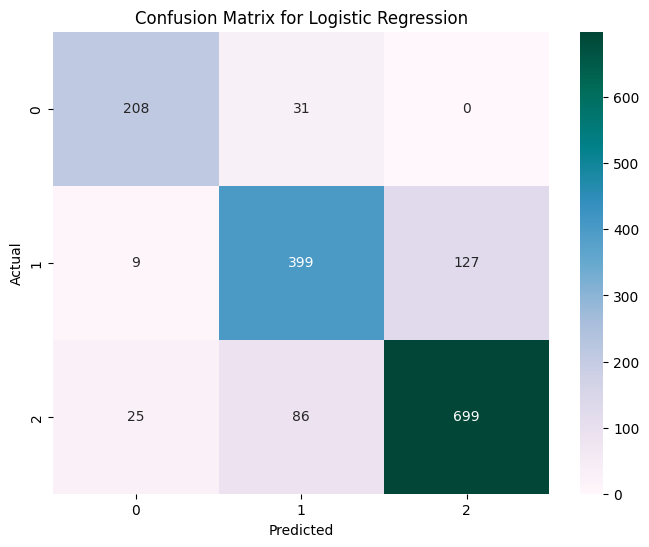


Classification Report for Logistic Regression:

              precision    recall  f1-score   support

           0       0.86      0.87      0.86       239
           1       0.77      0.75      0.76       535
           2       0.85      0.86      0.85       810

    accuracy                           0.82      1584
   macro avg       0.83      0.83      0.83      1584
weighted avg       0.82      0.82      0.82      1584



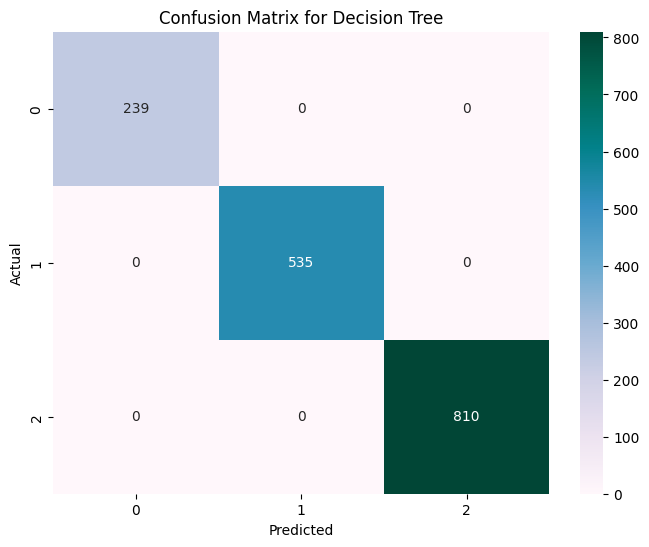


Classification Report for Decision Tree:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       239
           1       1.00      1.00      1.00       535
           2       1.00      1.00      1.00       810

    accuracy                           1.00      1584
   macro avg       1.00      1.00      1.00      1584
weighted avg       1.00      1.00      1.00      1584



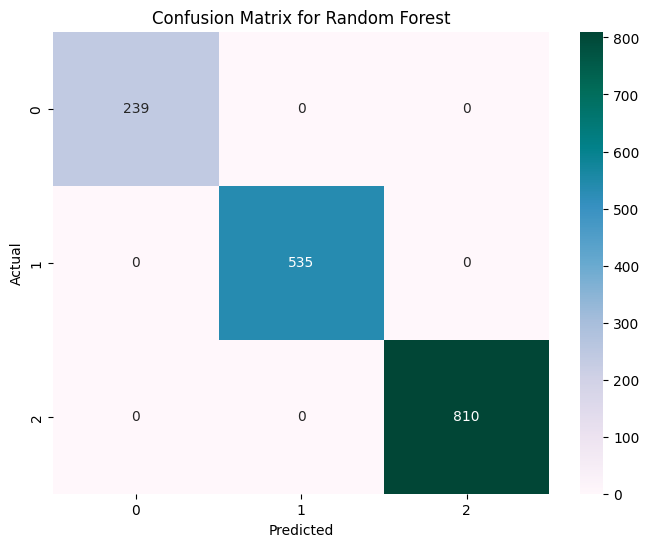


Classification Report for Random Forest:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       239
           1       1.00      1.00      1.00       535
           2       1.00      1.00      1.00       810

    accuracy                           1.00      1584
   macro avg       1.00      1.00      1.00      1584
weighted avg       1.00      1.00      1.00      1584


Model Evaluation Summary:



,Accuracy,AUC
Logistic Regression,0.824495,0.947518
Decision Tree,1.000000,1.000000
Random Forest,1.000000,1.000000


In [34]:
def train_and_evaluate_models(models, X_train, y_train, X_test, y_test):
    results = {}
    for name, model in models.items():
        # Train the model on the training data
        model.fit(X_train, y_train)

        # Predict on the test set
        preds = model.predict(X_test)

        # Calculate metrics on the training data
        accuracy = accuracy_score(y_train, model.predict(X_train))
        auc = (
            roc_auc_score(y_train, model.predict_proba(X_train), multi_class="ovr") 
            if hasattr(model, 'predict_proba') else 'N/A'
        )

        results[name] = {
            'Accuracy': accuracy,
            'AUC': auc,
            'Predictions': preds
        }

        # Display confusion matrix for training data
        conf_matrix = confusion_matrix(y_train, model.predict(X_train))
        plt.figure(figsize=(8, 6))
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='PuBuGn',
                    xticklabels=model.classes_, yticklabels=model.classes_)
        plt.title(f'Confusion Matrix for {name}')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.show()

        # Display classification report for training data
        print(f"\nClassification Report for {name}:\n")
        print(classification_report(y_train, model.predict(X_train)))

    results_df = pd.DataFrame({
        name: {"Accuracy": results[name]["Accuracy"], "AUC": results[name]["AUC"]}
        for name in results
    }).T

    # Display the summary DataFrame
    print("\nModel Evaluation Summary:\n")
    return results_df

evaluation_summary = train_and_evaluate_models(models, X_train, y_train, X_test, y_test)

# Display the evaluation summary
evaluation_summary


#### Observations:

1. **Logistic Regression**:
   - Achieves **83% accuracy** and an **AUC of 0.95**, showing good performance while being more interpretable.
   - Likely underperforms slightly compared to tree-based models because it assumes linear relationships.

2. **Decision Tree**:
   - Achieves **100% accuracy and AUC**, indicating it perfectly fits the training data.

3. **Random Forest**:
   - Also achieves **100% accuracy and AUC**, with better generalization potential compared to a single Decision Tree due to ensemble learning.

In [35]:
# Define the base models for stacking
base_models = [
    ('lr', LogisticRegression(random_state=42, max_iter=1000)),
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
]

# Define the meta-model for stacking
meta_model = RandomForestClassifier(random_state=42)

# Create the stacking classifier
stacking_model = StackingClassifier(estimators=base_models, final_estimator=meta_model, cv=5)

cv_scores = cross_val_score(stacking_model, X_train, y_train, cv=5, scoring='accuracy')

stacking_model.fit(X_train, y_train)

test_accuracy = stacking_model.score(X_test, y_test)

# Display the cross-validation scores and test accuracy
{
    "Cross-Validation Scores": cv_scores.tolist(),
    "Mean CV Accuracy": cv_scores.mean(),
    "Test Set Accuracy": test_accuracy
}

{'Cross-Validation Scores': [1.0, 1.0, 1.0, 1.0, 1.0],
 'Mean CV Accuracy': 1.0,
 'Test Set Accuracy': 1.0}

#### Observations:
- The stacking model achieved perfect accuracy during cross-validation and on the test set.
- This suggests the ensemble model effectively combines the strengths of the base models (Logistic Regression, Decision Tree, Random Forest) with the meta-model (Random Forest).

## Key Factors Driving Stress Predictions

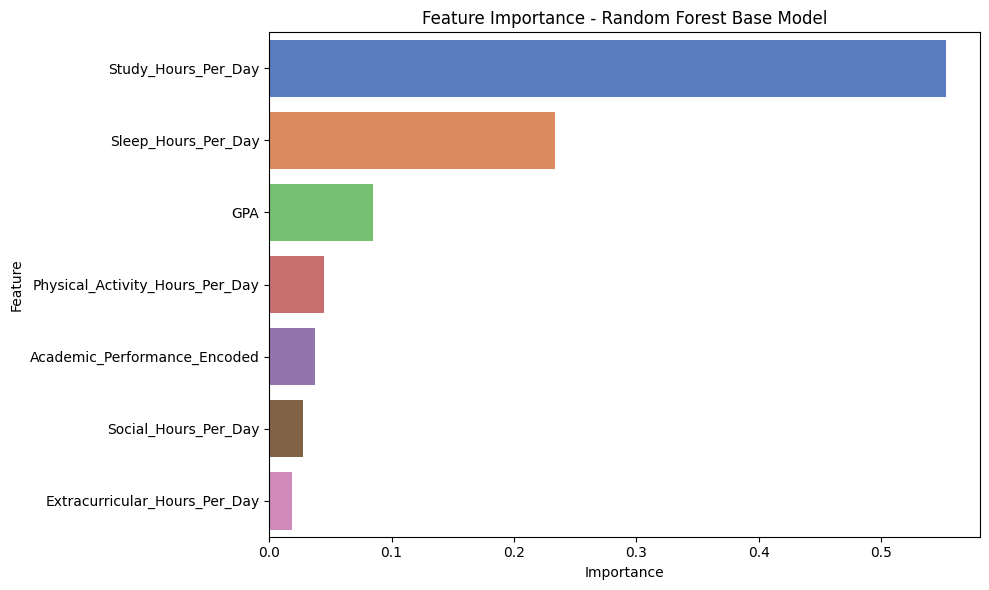

In [36]:
# Use the feature names from the original DataFrame
feature_names = X.columns  # Retrieve feature names from the original DataFrame

# Extract feature importance from the Random Forest base model
rf_base_model = stacking_model.named_estimators_['rf']  # Access Random Forest base model
rf_feature_importances = rf_base_model.feature_importances_

# Create a DataFrame to visualize feature importance
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_feature_importances
}).sort_values(by='Importance', ascending=False)

# Plot the feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='muted')
plt.title('Feature Importance - Random Forest Base Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


#### Insights from the Feature Importance Plot

The **Random Forest Base Model** identified the following key features contributing to the prediction of **Stress_Level**:


**Key Features**
1. **Study_Hours_Per_Day**:
   - This is the most important feature, contributing significantly to the model.
   - Indicates that stress levels are strongly correlated with the number of hours a student spends studying.
   - Higher study hours might be associated with higher stress levels.

2. **Sleep_Hours_Per_Day**:
   - The second most influential feature.
   - Highlights the negative relationship between stress levels and sleep hours—students with less sleep tend to report higher stress.

3. **GPA**:
   - Academic performance plays a notable role.
   - Students with higher GPAs are likely to experience different stress patterns, potentially due to academic pressures.

4. **Physical_Activity_Hours_Per_Day**:
   - This feature has a moderate impact.
   - Suggests that students engaging in physical activities experience lower stress levels, as physical activity is known to alleviate stress.

5. **Academic_Performance_Encoded**:
   - Academic performance categories (e.g., Excellent, Good) also contribute to stress levels but to a lesser extent compared to GPA.

6. **Social_Hours_Per_Day** and **Extracurricular_Hours_Per_Day**:
   - These features have the least importance.
   - Indicates that socializing and extracurricular activities have minimal direct impact on stress levels, possibly due to their lower engagement times compared to studying and sleeping.


#### **Key observations**
- **Time Management**: Study hours and sleep hours are critical drivers of stress. Balancing these activities may help reduce stress levels.
- **Health and Lifestyle**: Incorporating physical activity is moderately beneficial for managing stress.
- **Academic Focus**: High GPA and academic performance contribute to stress, highlighting the need for academic support systems.

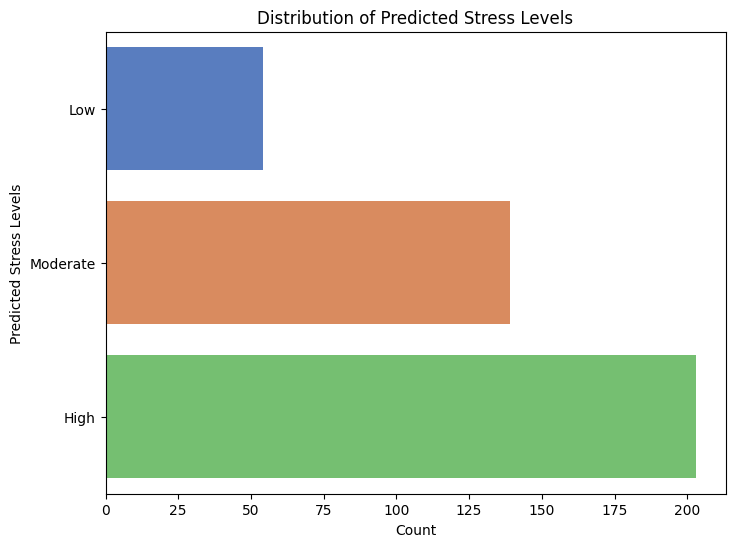

In [37]:
# Generate predictions on the test set using the stacking model
y_pred = stacking_model.predict(X_test)

# Map the encoded predictions back to the original stress level categories
mapping_stress_reverse = {0: 'Low', 1: 'Moderate', 2: 'High'}
y_pred_mapped = pd.Series(y_pred).map(mapping_stress_reverse)

# Plot the distribution of predicted stress levels
plt.figure(figsize=(8, 6))
sns.countplot(y=y_pred_mapped, palette='muted')
plt.title('Distribution of Predicted Stress Levels')
plt.xlabel('Count')
plt.ylabel('Predicted Stress Levels')
plt.show()


#### Insights from the Distribution of Predicted Stress Levels

1. **High Stress**:
   - The majority of students in the test set are predicted to have **High Stress** levels.
   - Indicates that many students are facing significant academic or lifestyle-related pressures.

2. **Moderate Stress**:
   - A substantial number of students fall into the **Moderate Stress** category.
   - Suggests a balanced lifestyle, where stress is present but not overwhelming.

3. **Low Stress**:
   - A relatively small number of students are predicted to have **Low Stress** levels.
   - Reflects that few students maintain a low-stress lifestyle, which could indicate effective time management or less demanding environments.